# Stage 02 - Transfer Learning từ backbone

## Cấu hình

In [1]:
# === CELL 1: CÀI ĐẶT MÔI TRƯỜNG ===
%pip install --upgrade pip --quiet
%pip install torch==2.14.0 torchvision --index-url https://download.pytorch.org/whl/xpu --quiet
print("✅ Hoàn tất kiểm tra và cài đặt thư viện!")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Hoàn tất kiểm tra và cài đặt thư viện!


In [2]:
# === CELL 2: IMPORT THƯ VIỆN & KHỞI TẠO XPU ===
import os
import io
import gc
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as tv_models

import optuna
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Tắt đa luồng nội bộ của OpenCV để tránh xung đột (deadlock) với PyTorch DataLoader workers
cv2.setNumThreads(0)
warnings.filterwarnings("ignore")

# --- Cố định Seed đảm bảo tính tái lập ---
SEED = 42
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        torch.xpu.manual_seed(seed)
        torch.xpu.manual_seed_all(seed)

seed_everything(SEED)

# --- Kiểm tra và cấu hình thiết bị Intel XPU ---
has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if has_xpu:
    DEVICE = torch.device("xpu:0")
    n_xpu = torch.xpu.device_count()
    print(f"✅ Đã phát hiện {n_xpu} thiết bị XPU:")
    for i in range(n_xpu):
        try:
            props = torch.xpu.get_device_properties(i)
            total_mem_gb = getattr(props, "total_memory", 0) / (1024**3)
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)} (Bộ nhớ khả dụng: {total_mem_gb:.2f} GB)")
        except Exception:
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Không phát hiện XPU khả dụng -> Fallback về CPU.")

# --- Bật Mixed Precision (bfloat16) ---
USE_AMP = True if has_xpu else False
AUTOCAST_DEVICE_TYPE = "xpu" if has_xpu else "cpu"
AUTOCAST_DTYPE = torch.bfloat16

print(f"\nPyTorch version   : {torch.__version__}")
print(f"Thiết bị sử dụng  : {DEVICE}")
print(f"Mixed Precision   : {USE_AMP} (dtype={AUTOCAST_DTYPE})")

/home/dainguyen1506/Documents/face-anti-spoofing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đã phát hiện 1 thiết bị XPU:
   - xpu:0 -> Intel(R) Graphics (Bộ nhớ khả dụng: 13.24 GB)

PyTorch version   : 2.14.0+xpu
Thiết bị sử dụng  : xpu:0
Mixed Precision   : True (dtype=torch.bfloat16)


In [3]:
# === CELL 3: CẤU HÌNH HỆ THỐNG & THAM SỐ CHUNG (STAGE 2) ===
PROJECT_ROOT   = Path("..").resolve()
DATASET_ROOT   = PROJECT_ROOT / "dataset"
MODELS_DIR     = PROJECT_ROOT / "models"
STAGE1_DIR     = PROJECT_ROOT / "checkpoint" / "stage1"
ARTIFACTS_DIR  = PROJECT_ROOT / "checkpoint" / "stage2"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET_SLUG = "faber24/lcc-fasd"

# --- Cấu hình Ảnh & Nhãn (Giữ nguyên từ Stage 1 để so sánh đồng nhất) ---
IMG_SIZE      = 192
NUM_CLASSES   = 2          # 0 = spoof (giả mạo), 1 = real (người thật)
LABEL2IDX     = {"spoof": 0, "real": 1}
IDX2LABEL     = {v: k for k, v in LABEL2IDX.items()}

# --- Tối ưu hóa Phần cứng (Máy 16GB RAM + Intel Core Ultra / XPU) ---
NUM_WORKERS            = 4
CPU_THREADS            = 12
CACHE_TRAIN_VAL_IN_RAM = True
MAX_SAFE_CACHE_MB      = 3000
USE_CHANNELS_LAST      = has_xpu
PIN_MEMORY             = has_xpu

torch.set_num_threads(CPU_THREADS)

# --- Kế thừa Siêu tham số Hàm Loss & Batch Size từ Stage 1 ---
STAGE1_BEST_PARAMS_PATH = STAGE1_DIR / "best_params_stage1.json"
MODEL1_BEST_CKPT_PATH   = MODELS_DIR / "model1_custom_cnn_best.pt"

DEFAULT_INHERITED_PARAMS = {
    "batch_size": 32,
    "focal_gamma": 2.0,
    "alpha_real": 0.55,
    "label_smoothing": 0.08,
}
if STAGE1_BEST_PARAMS_PATH.exists():
    with open(STAGE1_BEST_PARAMS_PATH, "r", encoding="utf-8") as f:
        s1_data = json.load(f)
        s1_params = s1_data.get("best_params", s1_data)
    for k in DEFAULT_INHERITED_PARAMS:
        if k in s1_params:
            DEFAULT_INHERITED_PARAMS[k] = s1_params[k]
    print(f"✅ Đã kế thừa tham số Loss & Batch từ Stage 1: {DEFAULT_INHERITED_PARAMS}")
else:
    print(f"ℹ️ Sử dụng tham số kế thừa mặc định từ báo cáo Stage 1: {DEFAULT_INHERITED_PARAMS}")

BATCH_SIZE      = int(DEFAULT_INHERITED_PARAMS["batch_size"])
FOCAL_GAMMA     = float(DEFAULT_INHERITED_PARAMS["focal_gamma"])
ALPHA_REAL      = float(DEFAULT_INHERITED_PARAMS["alpha_real"])
LABEL_SMOOTHING = float(DEFAULT_INHERITED_PARAMS["label_smoothing"])

# --- Pha 1: Cấu hình Sàng lọc Nhanh 3 Pretrained Backbones (Quick Screening) ---
CANDIDATE_BACKBONES    = ["mobilenet_v3_large", "efficientnet_b0", "resnet34"]
SCREEN_EPOCHS          = 6     # 2 epochs đóng băng + 4 epochs mở khóa toàn mạng
SCREEN_FREEZE_EPOCHS   = 2
SCREEN_STATE_JSON      = ARTIFACTS_DIR / "screening_state_stage2.json"
SCREEN_CSV_PATH        = ARTIFACTS_DIR / "screening_results_stage2.csv"

# --- Pha 2: Cấu hình Optuna Hyperparameter Tuning cho Backbone Vô địch ---
N_TRIALS               = 12    # Có thể tăng thêm nếu muốn chạy thêm trials nối tiếp
TUNE_EPOCHS            = 6
TUNE_TIMEOUT_SEC       = None
OPTUNA_STATE_JSON      = ARTIFACTS_DIR / "optuna_state_stage2.json"
OPTUNA_TRIALS_CSV      = ARTIFACTS_DIR / "optuna_trials_stage2.csv"
BEST_PARAMS_JSON       = ARTIFACTS_DIR / "best_params_stage2.json"

# --- Pha 3: Cấu hình Huấn luyện Toàn phần (Full Fine-Tuning) & Checkpoint ---
FULL_EPOCHS            = 50
EARLY_STOP_PATIENCE    = 12
LR_SCHEDULER_PATIENCE  = 3     # Giảm Learning Rate nếu sau 3 epoch mà val_ACER không cải thiện
LR_SCHEDULER_FACTOR    = 0.5   # Mỗi lần giảm sẽ nhân LR với 0.5

MODEL2_LATEST_CKPT_PATH = MODELS_DIR / "model2_transfer_latest.pt"
MODEL2_BEST_CKPT_PATH   = MODELS_DIR / "model2_transfer_best.pt"
HISTORY_CSV_PATH        = ARTIFACTS_DIR / "train_history_stage2.csv"
TRAIN_STATE_JSON        = ARTIFACTS_DIR / "training_state_stage2.json"

print("\n✅ Cấu hình hệ thống Stage 2 sẵn sàng!")
print(f"   - Ứng viên Backbones     : {CANDIDATE_BACKBONES}")
print(f"   - ARTIFACTS_DIR          : {ARTIFACTS_DIR}")
print(f"   - SCREEN_STATE_JSON      : {SCREEN_STATE_JSON.name}")
print(f"   - OPTUNA_STATE_JSON      : {OPTUNA_STATE_JSON.name}")
print(f"   - TRAIN_STATE_JSON       : {TRAIN_STATE_JSON.name}")

✅ Đã kế thừa tham số Loss & Batch từ Stage 1: {'batch_size': 32, 'focal_gamma': 2.0, 'alpha_real': 0.55, 'label_smoothing': 0.08}

✅ Cấu hình hệ thống Stage 2 sẵn sàng!
   - Ứng viên Backbones     : ['mobilenet_v3_large', 'efficientnet_b0', 'resnet34']
   - ARTIFACTS_DIR          : /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage2
   - SCREEN_STATE_JSON      : screening_state_stage2.json
   - OPTUNA_STATE_JSON      : optuna_state_stage2.json
   - TRAIN_STATE_JSON       : training_state_stage2.json


In [4]:
# === CELL 4: KIỂM TRA DỮ LIỆU LCC-FASD & LẬP DANH SÁCH MẪU ===
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def split_dirs_for(root: Path):
    return {
        "train": root / "LCC_FASD_training",
        "val":   root / "LCC_FASD_development",
        "test":  root / "LCC_FASD_evaluation",
    }

def count_images(folder: Path) -> int:
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS) if folder.is_dir() else 0

def split_ready(split_dir: Path) -> bool:
    return count_images(split_dir / "real") > 0 and count_images(split_dir / "spoof") > 0

def find_lcc_fasd_root():
    candidates = [DATASET_ROOT / "LCC_FASD", DATASET_ROOT]
    if DATASET_ROOT.exists():
        candidates += [p.parent for p in DATASET_ROOT.rglob("LCC_FASD_training") if p.is_dir()]
    seen = set()
    for root in candidates:
        root = root.resolve()
        if root in seen:
            continue
        seen.add(root)
        split_dirs = split_dirs_for(root)
        if all(split_ready(d) for d in split_dirs.values()):
            return root, split_dirs
    root = (DATASET_ROOT / "LCC_FASD").resolve()
    return root, split_dirs_for(root)

LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

if not dataset_ready:
    print(f"⚠️ Chưa tìm thấy LCC-FASD tại {LCC_FASD_ROOT} -> Đang tải từ Kaggle...")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(KAGGLE_DATASET_SLUG, path=str(DATASET_ROOT), unzip=True, quiet=False)
    LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
    dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

assert dataset_ready, f"❌ Dữ liệu LCC-FASD vẫn chưa đầy đủ tại {DATASET_ROOT}."

def list_samples(split_dir: Path):
    samples = []
    for label_name in ("spoof", "real"):
        label_idx = LABEL2IDX[label_name]
        label_dir = split_dir / label_name
        samples.extend(
            (str(p), label_idx)
            for p in sorted(label_dir.rglob("*"))
            if p.suffix.lower() in IMG_EXTS
        )
    return samples

train_samples = list_samples(SPLIT_DIRS["train"])
val_samples   = list_samples(SPLIT_DIRS["val"])
test_samples  = list_samples(SPLIT_DIRS["test"])

print(f"✅ Đã tìm thấy LCC-FASD tại: {LCC_FASD_ROOT}\n")
print("=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===")
for name, s_list in [("Train", train_samples), ("Val", val_samples), ("Test", test_samples)]:
    cnt = Counter(label for _, label in s_list)
    n_real, n_spoof = cnt.get(1, 0), cnt.get(0, 0)
    ratio = n_spoof / max(n_real, 1)
    print(f"  {name:5s}: {len(s_list):6d} ảnh | Real (1) = {n_real:5d} ({n_real/len(s_list)*100:5.1f}%) | Spoof (0) = {n_spoof:5d} ({n_spoof/len(s_list)*100:5.1f}%) | Tỉ lệ Spoof/Real = {ratio:.2f}:1")

✅ Đã tìm thấy LCC-FASD tại: /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD

=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===
  Train:   8299 ảnh | Real (1) =  1223 ( 14.7%) | Spoof (0) =  7076 ( 85.3%) | Tỉ lệ Spoof/Real = 5.79:1
  Val  :   2948 ảnh | Real (1) =   405 ( 13.7%) | Spoof (0) =  2543 ( 86.3%) | Tỉ lệ Spoof/Real = 6.28:1
  Test :   7580 ảnh | Real (1) =   314 (  4.1%) | Spoof (0) =  7266 ( 95.9%) | Tỉ lệ Spoof/Real = 23.14:1


In [5]:
# === CELL 5: TIỀN NẠP CACHE RAM ĐA LUỒNG ===
from concurrent.futures import ThreadPoolExecutor

def decode_and_resize_single(args):
    path, img_size = args
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

def build_shared_ram_cache(samples, img_size: int, desc: str = "Cache"):
    """Nạp toàn bộ danh sách ảnh vào Shared Memory Tensor (uint8) dùng đa luồng."""
    n = len(samples)
    est_mb = (n * img_size * img_size * 3) / (1024 ** 2)
    print(f"⏳ Đang nạp {desc} ({n} ảnh @ {img_size}x{img_size}) vào Shared RAM (~{est_mb:.1f} MB)...")
    t0 = time.time()

    shared_tensor = torch.empty((n, img_size, img_size, 3), dtype=torch.uint8).share_memory_()
    shared_np = shared_tensor.numpy()

    tasks = [(path, img_size) for path, _ in samples]
    with ThreadPoolExecutor(max_workers=CPU_THREADS) as executor:
        for idx, img in enumerate(tqdm(executor.map(decode_and_resize_single, tasks), total=n, desc=desc, leave=False)):
            shared_np[idx] = img

    print(f"✅ Hoàn tất nạp {desc} trong {time.time() - t0:.2f}s! (Chiếm {est_mb:.1f} MB RAM cố định)")
    return shared_tensor

est_train_val_mb = (len(train_samples) + len(val_samples)) * (IMG_SIZE ** 2) * 3 / (1024 ** 2)
if CACHE_TRAIN_VAL_IN_RAM and est_train_val_mb <= MAX_SAFE_CACHE_MB:
    train_ram_cache = build_shared_ram_cache(train_samples, IMG_SIZE, desc="Train Split")
    val_ram_cache   = build_shared_ram_cache(val_samples, IMG_SIZE, desc="Val Split")
else:
    print("⚠️ Bỏ qua Cache RAM -> Đọc trực tiếp từ ổ cứng.")
    train_ram_cache = None
    val_ram_cache   = None

⏳ Đang nạp Train Split (8299 ảnh @ 192x192) vào Shared RAM (~875.3 MB)...


✅ Hoàn tất nạp Train Split trong 9.55s! (Chiếm 875.3 MB RAM cố định)
⏳ Đang nạp Val Split (2948 ảnh @ 192x192) vào Shared RAM (~310.9 MB)...


✅ Hoàn tất nạp Val Split trong 3.22s! (Chiếm 310.9 MB RAM cố định)


In [6]:
# === CELL 6: THIẾT LẬP AUGMENTATION & CLASS FASDataset ===
class FASDataset(Dataset):
    """Dataset Face Anti-Spoofing hỗ trợ đọc từ Shared Memory Tensor hoặc ổ cứng."""
    def __init__(self, samples, img_size: int, transform=None, shared_cache: torch.Tensor = None):
        self.samples = samples
        self.img_size = img_size
        self.transform = transform
        self.shared_cache = shared_cache

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if self.shared_cache is not None:
            img = self.shared_cache[idx].numpy().copy()
        else:
            img = decode_and_resize_single((path, self.img_size))

        if self.transform is not None:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)

# --- Chuẩn hóa theo ImageNet Mean/Std (Bắt buộc cho Pretrained Backbones) ---
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4,
    ),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.4),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.ImageCompression(quality_range=(55, 95), p=1.0),
        A.GaussNoise(std_range=(0.01, 0.05), p=1.0),
    ], p=0.35),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(12, 24),
        hole_width_range=(12, 24),
        fill=0,
        p=0.25,
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_ds = FASDataset(train_samples, IMG_SIZE, transform=train_transform, shared_cache=train_ram_cache)
val_ds   = FASDataset(val_samples,   IMG_SIZE, transform=eval_transform,  shared_cache=val_ram_cache)
test_ds  = FASDataset(test_samples,  IMG_SIZE, transform=eval_transform,  shared_cache=None)

print(f"\n📦 Khởi tạo Dataset hoàn tất: train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")


📦 Khởi tạo Dataset hoàn tất: train=8299 | val=2948 | test=7580


In [7]:
# === CELL 7: TẠO WEIGHTED RANDOM SAMPLER & HÀM DATALOADER (AN TOÀN CHO 16GB RAM + XPU) ===
def build_weighted_sampler(samples):
    labels = [label for _, label in samples]
    counts = Counter(labels)
    class_weights = {cls: 1.0 / max(cnt, 1) for cls, cnt in counts.items()}
    sample_weights = torch.DoubleTensor([class_weights[label] for label in labels])
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

def make_dataloaders(batch_size: int = BATCH_SIZE):
    sampler = build_weighted_sampler(train_samples)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader

print(f"✅ Đã cấu hình hàm make_dataloaders (batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS})!")

✅ Đã cấu hình hàm make_dataloaders (batch_size=32, num_workers=4)!


In [8]:
# === CELL 8: KIẾN TRÚC TRANSFER LEARNING (TransferFASNet - TỐI ƯU AN TOÀN CHO INTEL XPU) ===
def disable_inplace_activations(module: nn.Module):
    """
    Tắt cờ inplace=True trong các hàm kích hoạt của torchvision (Hardswish, Hardsigmoid, ReLU, SiLU)
    để ngăn chặn lỗi Segmentation Fault / Kernel Crash trên backend Intel XPU với bfloat16.
    """
    for m in module.modules():
        if hasattr(m, "inplace") and isinstance(m.inplace, bool):
            m.inplace = False


class TransferFASNet(nn.Module):
    """
    Mô hình Transfer Learning thống nhất cho Face Anti-Spoofing.
    Hỗ trợ 3 Pretrained Backbones:
      - 'mobilenet_v3_large' (out_channels = 960)
      - 'efficientnet_b0'    (out_channels = 1280)
      - 'resnet34'           (out_channels = 512)
    """
    def __init__(
        self,
        backbone_name: str = "efficientnet_b0",
        num_classes: int = NUM_CLASSES,
        dropout_rate: float = 0.35,
        pretrained: bool = True,
    ):
        super().__init__()
        self.backbone_name = backbone_name.lower()
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.backbone_frozen = False

        if self.backbone_name == "mobilenet_v3_large":
            weights = tv_models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
            base = tv_models.mobilenet_v3_large(weights=weights)
            self.encoder = base.features
            self.out_channels = 960

        elif self.backbone_name == "efficientnet_b0":
            weights = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            base = tv_models.efficientnet_b0(weights=weights)
            self.encoder = base.features
            self.out_channels = 1280

        elif self.backbone_name == "resnet34":
            weights = tv_models.ResNet34_Weights.DEFAULT if pretrained else None
            base = tv_models.resnet34(weights=weights)
            self.encoder = nn.Sequential(
                base.conv1,
                base.bn1,
                base.relu,
                base.maxpool,
                base.layer1,
                base.layer2,
                base.layer3,
                base.layer4,
            )
            self.out_channels = 512
        else:
            raise ValueError(f"❌ Không hỗ trợ backbone: {backbone_name}")

        # Bắt buộc tắt inplace=True trong encoder để chạy an toàn trên Intel XPU
        disable_inplace_activations(self.encoder)

        # Dual Pooling (Avg + Max)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.feature_dim = self.out_channels * 2

        # Classification Head mới cho bài toán FAS (inplace=False giống Stage 1)
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=False),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward_feature_map(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        fmap = self.forward_feature_map(x)
        avg_f = self.avg_pool(fmap).flatten(1)
        max_f = self.max_pool(fmap).flatten(1)
        return torch.cat([avg_f, max_f], dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.backbone_frozen:
            with torch.no_grad():
                feats = self.extract_features(x)
        else:
            feats = self.extract_features(x)
        return self.classifier(feats)

    def set_backbone_trainable(self, trainable: bool = True):
        self.backbone_frozen = not trainable
        for param in self.encoder.parameters():
            param.requires_grad = trainable
        if not trainable:
            self.encoder.eval()

    def train(self, mode: bool = True):
        super().train(mode)
        if mode and self.backbone_frozen:
            self.encoder.eval()
        return self

# Kiểm tra nhanh kích thước tham số trên CPU (tránh mở context XPU sớm trước khi fork DataLoader)
print("=== KIỂM TRA KIẾN TRÚC 3 ỨNG VIÊN PRETRAINED BACKBONES ===")
_dummy_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
for _bname in CANDIDATE_BACKBONES:
    _m = TransferFASNet(_bname, pretrained=False).eval()
    with torch.no_grad():
        _fmap = _m.forward_feature_map(_dummy_x)
        _feat = _m.extract_features(_dummy_x)
        _out  = _m(_dummy_x)
    _total_p = sum(p.numel() for p in _m.parameters()) / 1e6
    print(f"  - {_bname:20s} | Tổng tham số: {_total_p:5.2f}M | FeatureMap: {tuple(_fmap.shape)} | FeatureVec: {_feat.shape[1]}D | Logits: {tuple(_out.shape)}")
    del _m, _fmap, _feat, _out
del _dummy_x

=== KIỂM TRA KIẾN TRÚC 3 ỨNG VIÊN PRETRAINED BACKBONES ===
  - mobilenet_v3_large   | Tổng tham số:  3.46M | FeatureMap: (2, 960, 6, 6) | FeatureVec: 1920D | Logits: (2, 2)
  - efficientnet_b0      | Tổng tham số:  4.66M | FeatureMap: (2, 1280, 6, 6) | FeatureVec: 2560D | Logits: (2, 2)
  - resnet34             | Tổng tham số: 21.55M | FeatureMap: (2, 512, 6, 6) | FeatureVec: 1024D | Logits: (2, 2)


In [9]:
# === CELL 9: HÀM LOSS (FOCAL LOSS + LABEL SMOOTHING) & CHỈ SỐ ISO/IEC 30107-3 ===
class FocalLossWithSmoothing(nn.Module):
    """
    Kết hợp Focal Loss và Label Smoothing kế thừa từ Stage 1:
      - gamma: Tập trung vào các mẫu khó (hard examples).
      - alpha_real: Trọng số cân bằng cho lớp Real (1).
      - smoothing: Làm mượt nhãn giúp tránh overconfidence khi Fine-tune.
    """
    def __init__(self, gamma: float = 2.0, alpha_real: float = 0.55, smoothing: float = 0.08):
        super().__init__()
        self.gamma = gamma
        self.alpha_real = alpha_real
        self.smoothing = smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / num_classes)
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing + (self.smoothing / num_classes))

        log_probs = F.log_softmax(logits.float(), dim=-1)
        probs = torch.exp(log_probs)

        pt = (true_dist * probs).sum(dim=-1)
        ce_smooth = -(true_dist * log_probs).sum(dim=-1)

        alpha_t = torch.where(targets == 1, self.alpha_real, 1.0 - self.alpha_real)
        focal_weight = alpha_t * ((1.0 - pt) ** self.gamma)

        return (focal_weight * ce_smooth).mean()


def compute_fas_metrics(y_true: np.ndarray, y_prob_real: np.ndarray, fixed_threshold: float = None):
    """
    Tính toán bộ chỉ số chuẩn quốc tế ISO/IEC 30107-3:
      - APCER: Tỷ lệ mẫu Spoof (0) bị nhận nhầm thành Real (1).
      - BPCER: Tỷ lệ mẫu Real (1) bị từ chối nhầm thành Spoof (0).
      - ACER : (APCER + BPCER) / 2.
      - EER  : Điểm cân bằng lỗi trên đường cong ROC (APCER = BPCER).
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob_real, dtype=np.float64)

    auc = float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1.0 - tpr  # BPCER = FNR, APCER = FPR

    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer_threshold = float(thresholds[eer_idx])
    eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)

    thresh = float(eer_threshold if fixed_threshold is None else fixed_threshold)
    y_pred = (y_prob >= thresh).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    apcer = float(fp / max(tn + fp, 1))
    bpcer = float(fn / max(tp + fn, 1))
    acer  = float((apcer + bpcer) / 2.0)
    acc   = float((tp + tn) / max(tp + tn + fp + fn, 1))

    return {
        "threshold": thresh,
        "eer_threshold": eer_threshold,
        "APCER": apcer * 100.0,
        "BPCER": bpcer * 100.0,
        "ACER": acer * 100.0,
        "EER": eer * 100.0,
        "AUC": auc * 100.0,
        "ACC": acc * 100.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

print("✅ Đã khởi tạo FocalLossWithSmoothing và hàm đánh giá chuẩn ISO/IEC 30107-3!")

✅ Đã khởi tạo FocalLossWithSmoothing và hàm đánh giá chuẩn ISO/IEC 30107-3!


In [10]:
# === CELL 10: HÀM TRAIN / EVALUATE & DIFFERENTIAL LR OPTIMIZER (CHUẨN XPU) ===
def build_differential_optimizer(
    model: TransferFASNet,
    lr_head: float,
    backbone_lr_ratio: float,
    weight_decay: float,
):
    lr_backbone = lr_head * backbone_lr_ratio
    param_groups = [
        {"params": list(model.encoder.parameters()),    "lr": lr_backbone, "name": "backbone"},
        {"params": list(model.classifier.parameters()), "lr": lr_head,     "name": "head"},
    ]
    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


def train_one_epoch(model: TransferFASNet, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    running_loss = 0.0
    total_samples = 0
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    for images, labels in loader:
        if USE_CHANNELS_LAST:
            images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        loss.backward()
        if trainable_params:
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=2.0)
        optimizer.step()

        bs = labels.size(0)
        running_loss += float(loss.detach().item()) * bs
        total_samples += bs

    if has_xpu:
        torch.xpu.synchronize()
    return running_loss / max(total_samples, 1)


@torch.no_grad()
def evaluate_model(model: TransferFASNet, loader: DataLoader, criterion: nn.Module, fixed_threshold: float = None):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    all_labels = []
    all_probs_real = []

    for images, labels in loader:
        if USE_CHANNELS_LAST:
            images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(DEVICE, non_blocking=True)
        labels_dev = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels_dev)
            probs_real = F.softmax(logits.float(), dim=-1)[:, 1]

        bs = labels.size(0)
        running_loss += float(loss.detach().item()) * bs
        total_samples += bs

        all_labels.append(labels.numpy())
        all_probs_real.append(probs_real.cpu().numpy())

    if has_xpu:
        torch.xpu.synchronize()

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs_real)
    metrics = compute_fas_metrics(y_true, y_prob, fixed_threshold=fixed_threshold)
    metrics["loss"] = running_loss / max(total_samples, 1)
    metrics["y_true"] = y_true
    metrics["y_prob"] = y_prob
    return metrics

print("✅ Các hàm train_one_epoch, evaluate_model và build_differential_optimizer (Bản vá XPU) đã sẵn sàng!")

✅ Các hàm train_one_epoch, evaluate_model và build_differential_optimizer (Bản vá XPU) đã sẵn sàng!


In [11]:
# === CELL 11: PHA 1 - SÀNG LỌC NHANH 3 PRETRAINED BACKBONES (QUICK SCREENING) ===
SCREEN_DEFAULT_LR_HEAD = 1e-3
SCREEN_DEFAULT_BACKBONE_RATIO = 0.15
SCREEN_DEFAULT_WEIGHT_DECAY = 5e-3
SCREEN_DEFAULT_DROPOUT = 0.35

screening_config_signature = {
    "candidate_backbones": CANDIDATE_BACKBONES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "freeze_epochs": SCREEN_FREEZE_EPOCHS,
    "lr_head": SCREEN_DEFAULT_LR_HEAD,
    "backbone_lr_ratio": SCREEN_DEFAULT_BACKBONE_RATIO,
    "weight_decay": SCREEN_DEFAULT_WEIGHT_DECAY,
    "dropout_rate": SCREEN_DEFAULT_DROPOUT,
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
}

screening_state = {
    "config": screening_config_signature,
    "target_epochs": SCREEN_EPOCHS,
    "backbones": {},
    "winner_backbone": None,
}

if SCREEN_STATE_JSON.exists():
    try:
        with open(SCREEN_STATE_JSON, "r", encoding="utf-8") as f:
            loaded_screen = json.load(f)
        if loaded_screen.get("config") == screening_config_signature:
            screening_state = loaded_screen
            screening_state["target_epochs"] = SCREEN_EPOCHS
            print("♻️ Phát hiện Checkpoint Sàng lọc hợp lệ (Cấu hình không đổi) -> Kiểm tra tiến độ từng Backbone...")
        else:
            print("🔄 Cấu hình Sàng lọc thay đổi so với lần trước -> Chạy sàng lọc lại từ đầu!")
    except Exception as e:
        print(f"⚠️ Không đọc được file trạng thái sàng lọc cũ ({e}) -> Chạy lại từ đầu.")

screen_criterion = FocalLossWithSmoothing(
    gamma=FOCAL_GAMMA, alpha_real=ALPHA_REAL, smoothing=LABEL_SMOOTHING
).to(DEVICE)

for bname in CANDIDATE_BACKBONES:
    b_info = screening_state["backbones"].get(bname, {
        "last_epoch": 0,
        "best_val_acer": 100.0,
        "best_val_auc": 0.0,
        "best_val_apcer": 100.0,
        "best_val_bpcer": 100.0,
        "best_epoch": 0,
        "elapsed_sec": 0.0,
        "history": [],
    })
    last_ep = int(b_info.get("last_epoch", 0))
    b_ckpt_path = ARTIFACTS_DIR / f"screen_{bname}_latest.pt"

    if last_ep >= SCREEN_EPOCHS:
        print(f"✅ [{bname}] Đã hoàn tất sàng lọc ({last_ep}/{SCREEN_EPOCHS} epochs) | Best Val ACER = {b_info['best_val_acer']:.2f}% (Epoch {b_info['best_epoch']})")
        continue

    print(f"\n🚀 Đang chạy sàng lọc Backbone: [{bname}] từ Epoch {last_ep + 1} -> {SCREEN_EPOCHS}...")
    seed_everything(SEED)

    # Tải mô hình trên CPU trước, sau đó chuyển sang XPU để tránh xung đột luồng tải mạng với XPU
    model = TransferFASNet(
        backbone_name=bname, num_classes=NUM_CLASSES, dropout_rate=SCREEN_DEFAULT_DROPOUT, pretrained=True
    )
    if USE_CHANNELS_LAST:
        model = model.to(DEVICE, memory_format=torch.channels_last)
    else:
        model = model.to(DEVICE)

    optimizer = build_differential_optimizer(
        model,
        lr_head=SCREEN_DEFAULT_LR_HEAD,
        backbone_lr_ratio=SCREEN_DEFAULT_BACKBONE_RATIO,
        weight_decay=SCREEN_DEFAULT_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=2
    )

    if last_ep > 0 and b_ckpt_path.exists():
        ckpt = torch.load(b_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        print(f"   ↪ Đã nạp lại trọng số & optimizer của [{bname}] tại Epoch {last_ep}.")

    screen_train_loader, screen_val_loader = make_dataloaders(batch_size=BATCH_SIZE)

    for ep in range(last_ep + 1, SCREEN_EPOCHS + 1):
        t_ep = time.time()
        is_frozen = (ep <= SCREEN_FREEZE_EPOCHS)
        model.set_backbone_trainable(trainable=not is_frozen)
        phase_tag = "FROZEN-WARMUP" if is_frozen else "UNFROZEN-FINETUNE"

        tr_loss = train_one_epoch(model, screen_train_loader, screen_criterion, optimizer)
        val_res = evaluate_model(model, screen_val_loader, screen_criterion)
        scheduler.step(val_res["ACER"])

        ep_sec = time.time() - t_ep
        b_info["elapsed_sec"] = float(b_info.get("elapsed_sec", 0.0) + ep_sec)
        b_info["last_epoch"] = ep

        ep_record = {
            "backbone": bname,
            "epoch": ep,
            "phase": phase_tag,
            "train_loss": round(tr_loss, 5),
            "val_loss": round(val_res["loss"], 5),
            "val_APCER": round(val_res["APCER"], 3),
            "val_BPCER": round(val_res["BPCER"], 3),
            "val_ACER": round(val_res["ACER"], 3),
            "val_AUC": round(val_res["AUC"], 3),
            "epoch_sec": round(ep_sec, 2),
        }
        b_info["history"].append(ep_record)

        is_best = val_res["ACER"] < b_info["best_val_acer"]
        if is_best:
            b_info["best_val_acer"]  = float(val_res["ACER"])
            b_info["best_val_apcer"] = float(val_res["APCER"])
            b_info["best_val_bpcer"] = float(val_res["BPCER"])
            b_info["best_val_auc"]   = float(val_res["AUC"])
            b_info["best_epoch"]     = int(ep)

        # Lưu state_dict về CPU trước khi ghi đĩa để tránh lỗi cấp phát bộ nhớ XPU
        cpu_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save({
            "epoch": ep,
            "model_state_dict": cpu_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, b_ckpt_path)

        screening_state["backbones"][bname] = b_info
        with open(SCREEN_STATE_JSON, "w", encoding="utf-8") as f:
            json.dump(screening_state, f, indent=2, ensure_ascii=False)

        star = "⭐ KỶ LỤC" if is_best else ""
        print(
            f"   [{bname} | Ep {ep:02d}/{SCREEN_EPOCHS:02d} | {phase_tag:17s}] "
            f"TrainLoss={tr_loss:.4f} | Val ACER={val_res['ACER']:.2f}% "
            f"(APCER={val_res['APCER']:.2f}%, BPCER={val_res['BPCER']:.2f}%) | "
            f"AUC={val_res['AUC']:.2f}% | {ep_sec:.1f}s {star}"
        )

    del screen_train_loader, screen_val_loader, model, optimizer, scheduler
    gc.collect()
    if has_xpu:
        torch.xpu.empty_cache()

# --- Tổng hợp Bảng xếp hạng 3 Pretrained Backbones & Chốt WINNER_BACKBONE ---
summary_rows = []
for bname in CANDIDATE_BACKBONES:
    bi = screening_state["backbones"][bname]
    summary_rows.append({
        "Backbone": bname,
        "Best_Epoch": bi["best_epoch"],
        "Best_Val_ACER (%)": round(bi["best_val_acer"], 2),
        "Val_APCER (%)": round(bi["best_val_apcer"], 2),
        "Val_BPCER (%)": round(bi["best_val_bpcer"], 2),
        "Val_AUC (%)": round(bi["best_val_auc"], 2),
        "Total_Time (min)": round(bi["elapsed_sec"] / 60.0, 2),
    })

screen_df = pd.DataFrame(summary_rows).sort_values(by=["Best_Val_ACER (%)", "Val_AUC (%)"], ascending=[True, False]).reset_index(drop=True)
screen_df.to_csv(SCREEN_CSV_PATH, index=False)

WINNER_BACKBONE = str(screen_df.loc[0, "Backbone"])
screening_state["winner_backbone"] = WINNER_BACKBONE
with open(SCREEN_STATE_JSON, "w", encoding="utf-8") as f:
    json.dump(screening_state, f, indent=2, ensure_ascii=False)

print("\n" + "="*80)
print("🏆 BẢNG XẾP HẠNG SÀNG LỌC 3 PRETRAINED BACKBONES (STAGE 2):")
print("="*80)
display(screen_df)
print(f"\n🎯 CHỐT BACKBONE VÔ ĐỊCH CHO MODEL 2: 👉 '{WINNER_BACKBONE}' (Best Val ACER = {screen_df.loc[0, 'Best_Val_ACER (%)']:.2f}%)")


🚀 Đang chạy sàng lọc Backbone: [mobilenet_v3_large] từ Epoch 1 -> 6...
   [mobilenet_v3_large | Ep 01/06 | FROZEN-WARMUP    ] TrainLoss=0.0427 | Val ACER=19.00% (APCER=18.99%, BPCER=19.01%) | AUC=89.38% | 72.6s ⭐ KỶ LỤC
   [mobilenet_v3_large | Ep 02/06 | FROZEN-WARMUP    ] TrainLoss=0.0300 | Val ACER=14.30% (APCER=14.27%, BPCER=14.32%) | AUC=93.10% | 21.0s ⭐ KỶ LỤC
   [mobilenet_v3_large | Ep 03/06 | UNFROZEN-FINETUNE] TrainLoss=0.0201 | Val ACER=5.71% (APCER=5.74%, BPCER=5.68%) | AUC=98.12% | 67.8s ⭐ KỶ LỤC
   [mobilenet_v3_large | Ep 04/06 | UNFROZEN-FINETUNE] TrainLoss=0.0084 | Val ACER=5.51% (APCER=5.58%, BPCER=5.43%) | AUC=98.74% | 60.9s ⭐ KỶ LỤC
   [mobilenet_v3_large | Ep 05/06 | UNFROZEN-FINETUNE] TrainLoss=0.0056 | Val ACER=6.86% (APCER=6.80%, BPCER=6.91%) | AUC=98.72% | 61.0s 
   [mobilenet_v3_large | Ep 06/06 | UNFROZEN-FINETUNE] TrainLoss=0.0050 | Val ACER=3.92% (APCER=3.89%, BPCER=3.95%) | AUC=99.50% | 60.6s ⭐ KỶ LỤC

🚀 Đang chạy sàng lọc Backbone: [efficientnet_b0] từ E

100%|██████████| 20.5M/20.5M [00:00<00:00, 54.7MB/s]


   [efficientnet_b0 | Ep 01/06 | FROZEN-WARMUP    ] TrainLoss=0.0472 | Val ACER=19.30% (APCER=19.35%, BPCER=19.26%) | AUC=88.37% | 33.7s ⭐ KỶ LỤC
   [efficientnet_b0 | Ep 02/06 | FROZEN-WARMUP    ] TrainLoss=0.0327 | Val ACER=20.25% (APCER=20.25%, BPCER=20.25%) | AUC=89.33% | 31.4s 
   [efficientnet_b0 | Ep 03/06 | UNFROZEN-FINETUNE] TrainLoss=0.0273 | Val ACER=11.38% (APCER=11.40%, BPCER=11.36%) | AUC=96.22% | 109.9s ⭐ KỶ LỤC
   [efficientnet_b0 | Ep 04/06 | UNFROZEN-FINETUNE] TrainLoss=0.0103 | Val ACER=5.37% (APCER=5.31%, BPCER=5.43%) | AUC=98.77% | 95.4s ⭐ KỶ LỤC
   [efficientnet_b0 | Ep 05/06 | UNFROZEN-FINETUNE] TrainLoss=0.0080 | Val ACER=6.45% (APCER=6.49%, BPCER=6.42%) | AUC=98.07% | 96.4s 
   [efficientnet_b0 | Ep 06/06 | UNFROZEN-FINETUNE] TrainLoss=0.0055 | Val ACER=4.18% (APCER=4.17%, BPCER=4.20%) | AUC=98.87% | 100.8s ⭐ KỶ LỤC

🚀 Đang chạy sàng lọc Backbone: [resnet34] từ Epoch 1 -> 6...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/dai

100%|██████████| 83.3M/83.3M [00:01<00:00, 45.1MB/s]


   [resnet34 | Ep 01/06 | FROZEN-WARMUP    ] TrainLoss=0.0534 | Val ACER=18.26% (APCER=18.25%, BPCER=18.27%) | AUC=91.47% | 61.3s ⭐ KỶ LỤC
   [resnet34 | Ep 02/06 | FROZEN-WARMUP    ] TrainLoss=0.0396 | Val ACER=18.50% (APCER=18.48%, BPCER=18.52%) | AUC=90.05% | 59.6s 
   [resnet34 | Ep 03/06 | UNFROZEN-FINETUNE] TrainLoss=0.0250 | Val ACER=9.35% (APCER=9.32%, BPCER=9.38%) | AUC=95.82% | 175.4s ⭐ KỶ LỤC
   [resnet34 | Ep 04/06 | UNFROZEN-FINETUNE] TrainLoss=0.0106 | Val ACER=8.61% (APCER=8.57%, BPCER=8.64%) | AUC=96.25% | 171.9s ⭐ KỶ LỤC
   [resnet34 | Ep 05/06 | UNFROZEN-FINETUNE] TrainLoss=0.0083 | Val ACER=8.09% (APCER=8.02%, BPCER=8.15%) | AUC=98.29% | 172.1s ⭐ KỶ LỤC
   [resnet34 | Ep 06/06 | UNFROZEN-FINETUNE] TrainLoss=0.0065 | Val ACER=6.17% (APCER=6.17%, BPCER=6.17%) | AUC=98.16% | 171.4s ⭐ KỶ LỤC

🏆 BẢNG XẾP HẠNG SÀNG LỌC 3 PRETRAINED BACKBONES (STAGE 2):


,Backbone,Best_Epoch,Best_Val_ACER (%),Val_APCER (%),Val_BPCER (%),Val_AUC (%),Total_Time (min)
0,mobilenet_v3_large,6,3.92,3.89,3.95,99.50,5.73
1,efficientnet_b0,6,4.18,4.17,4.20,98.87,7.79
2,resnet34,6,6.17,6.17,6.17,98.16,13.53



🎯 CHỐT BACKBONE VÔ ĐỊCH CHO MODEL 2: 👉 'mobilenet_v3_large' (Best Val ACER = 3.92%)


In [12]:
# === CELL 12: PHA 2 - TỐI ƯU SIÊU THAM SỐ VỚI OPTUNA CHO WINNER_BACKBONE ===
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEARCH_SPACE_SPEC = {
    "lr_head_range": [3e-4, 2.5e-3],
    "backbone_lr_ratio_range": [0.05, 0.30],
    "weight_decay_range": [1e-4, 2e-2],
    "dropout_rate_range": [0.20, 0.50],
    "unfreeze_epoch_choices": [2, 3],
}

optuna_config_signature = {
    "winner_backbone": WINNER_BACKBONE,
    "tune_epochs": TUNE_EPOCHS,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
    "search_space": SEARCH_SPACE_SPEC,
    "seed": SEED,
}

# Đọc lại lịch sử các Trials từ Checkpoint JSON nếu cấu hình không đổi
saved_trials_records = []
if OPTUNA_STATE_JSON.exists():
    try:
        with open(OPTUNA_STATE_JSON, "r", encoding="utf-8") as f:
            loaded_opt = json.load(f)
        if loaded_opt.get("config") == optuna_config_signature:
            saved_trials_records = loaded_opt.get("trials", [])
            print(f"♻️ Phát hiện Checkpoint Optuna hợp lệ cho '{WINNER_BACKBONE}': Đã có {len(saved_trials_records)}/{N_TRIALS} trials.")
        else:
            print("🔄 Cấu hình Optuna hoặc Winner Backbone thay đổi -> Khởi tạo tìm kiếm Optuna mới!")
    except Exception as e:
        print(f"⚠️ Lỗi đọc Optuna state cũ ({e}) -> Chạy mới.")

# Khởi tạo Optuna Study (In-Memory) và nạp lại các Trials đã hoàn thành trước đó (nếu có)
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=2, interval_steps=1)
study   = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

distributions_map = {
    "lr_head": optuna.distributions.FloatDistribution(3e-4, 2.5e-3, log=True),
    "backbone_lr_ratio": optuna.distributions.FloatDistribution(0.05, 0.30, log=False),
    "weight_decay": optuna.distributions.FloatDistribution(1e-4, 2e-2, log=True),
    "dropout_rate": optuna.distributions.FloatDistribution(0.20, 0.50, step=0.05),
    "unfreeze_epoch": optuna.distributions.CategoricalDistribution([2, 3]),
}

for rec in saved_trials_records:
    st_name = rec.get("state", "COMPLETE")
    st_enum = optuna.trial.TrialState.COMPLETE if st_name == "COMPLETE" else optuna.trial.TrialState.PRUNED
    frozen_trial = optuna.trial.create_trial(
        params=rec["params"],
        distributions=distributions_map,
        value=rec["best_val_acer"],
        state=st_enum,
        user_attrs={"best_auc": rec.get("best_val_auc", 0.0), "elapsed_sec": rec.get("elapsed_sec", 0.0)},
    )
    study.add_trial(frozen_trial)

remaining_trials = max(0, N_TRIALS - len(saved_trials_records))

if remaining_trials == 0 and BEST_PARAMS_JSON.exists():
    print(f"✅ Đã hoàn tất đủ {len(saved_trials_records)}/{N_TRIALS} trials trước đó! Nạp trực tiếp bộ tham số tốt nhất.")
else:
    print(f"\n🔍 Bắt đầu chạy Optuna cho '{WINNER_BACKBONE}': Cần chạy thêm {remaining_trials} trials (Tổng mục tiêu: {N_TRIALS} trials x {TUNE_EPOCHS} epochs)...")
    tune_train_loader, tune_val_loader = make_dataloaders(batch_size=BATCH_SIZE)
    tune_criterion = FocalLossWithSmoothing(
        gamma=FOCAL_GAMMA, alpha_real=ALPHA_REAL, smoothing=LABEL_SMOOTHING
    ).to(DEVICE)

    def objective(trial: optuna.Trial):
        t0 = time.time()
        seed_everything(SEED + trial.number)

        lr_head           = trial.suggest_float("lr_head", 3e-4, 2.5e-3, log=True)
        backbone_lr_ratio = trial.suggest_float("backbone_lr_ratio", 0.05, 0.30)
        weight_decay      = trial.suggest_float("weight_decay", 1e-4, 2e-2, log=True)
        dropout_rate      = trial.suggest_float("dropout_rate", 0.20, 0.50, step=0.05)
        unfreeze_epoch    = trial.suggest_categorical("unfreeze_epoch", [2, 3])

        model = TransferFASNet(
            backbone_name=WINNER_BACKBONE,
            num_classes=NUM_CLASSES,
            dropout_rate=dropout_rate,
            pretrained=True,
        )
        if USE_CHANNELS_LAST:
            model = model.to(DEVICE, memory_format=torch.channels_last)
        else:
            model = model.to(DEVICE)

        optimizer = build_differential_optimizer(
            model, lr_head=lr_head, backbone_lr_ratio=backbone_lr_ratio, weight_decay=weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=1
        )

        best_acer = 100.0
        best_auc  = 0.0
        trial_state_str = "COMPLETE"

        try:
            for ep in range(1, TUNE_EPOCHS + 1):
                # Phương án A: Đóng băng trước unfreeze_epoch, mở khóa từ unfreeze_epoch trở đi
                model.set_backbone_trainable(trainable=(ep >= unfreeze_epoch))

                _ = train_one_epoch(model, tune_train_loader, tune_criterion, optimizer)
                val_res = evaluate_model(model, tune_val_loader, tune_criterion)
                val_acer = val_res["ACER"]
                scheduler.step(val_acer)

                if val_acer < best_acer:
                    best_acer = float(val_acer)
                    best_auc  = float(val_res["AUC"])

                trial.report(val_acer, step=ep)
                if trial.should_prune():
                    trial_state_str = "PRUNED"
                    raise optuna.TrialPruned()

        finally:
            elapsed = time.time() - t0
            trial.set_user_attr("best_auc", best_auc)
            trial.set_user_attr("elapsed_sec", elapsed)

            rec = {
                "trial_number": int(trial.number),
                "state": trial_state_str,
                "best_val_acer": round(best_acer, 4),
                "best_val_auc": round(best_auc, 4),
                "elapsed_sec": round(elapsed, 2),
                "params": {
                    "lr_head": lr_head,
                    "backbone_lr_ratio": backbone_lr_ratio,
                    "weight_decay": weight_decay,
                    "dropout_rate": dropout_rate,
                    "unfreeze_epoch": int(unfreeze_epoch),
                },
            }
            saved_trials_records.append(rec)

            # Lưu ngay trạng thái Optuna JSON & CSV sau mỗi Trial
            with open(OPTUNA_STATE_JSON, "w", encoding="utf-8") as f:
                json.dump({
                    "config": optuna_config_signature,
                    "target_trials": N_TRIALS,
                    "trials": saved_trials_records,
                }, f, indent=2, ensure_ascii=False)

            pd.DataFrame([
                {**r["params"], "trial": r["trial_number"], "state": r["state"], "best_val_acer": r["best_val_acer"], "best_val_auc": r["best_val_auc"], "sec": r["elapsed_sec"]}
                for r in saved_trials_records
            ]).to_csv(OPTUNA_TRIALS_CSV, index=False)

            tag = "✂️ PRUNED" if trial_state_str == "PRUNED" else "✅ DONE"
            print(
                f"   [Trial {trial.number:02d}/{N_TRIALS - 1:02d} | {tag:9s}] "
                f"Best Val ACER={best_acer:.2f}% (AUC={best_auc:.2f}%) | "
                f"lr_head={lr_head:.5f}, ratio={backbone_lr_ratio:.2f}, wd={weight_decay:.5f}, "
                f"drop={dropout_rate:.2f}, unfreeze_ep={unfreeze_epoch} | {elapsed:.1f}s"
            )

            del model, optimizer, scheduler
            gc.collect()
            if has_xpu:
                torch.xpu.empty_cache()

        return best_acer

    study.optimize(objective, n_trials=remaining_trials, timeout=TUNE_TIMEOUT_SEC)

# --- Xuất Bộ Siêu Tham Số Tối Ưu Nhất ra best_params_stage2.json ---
best_trial = study.best_trial
BEST_STAGE2_PARAMS = {
    "backbone_name": WINNER_BACKBONE,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "lr_head": float(best_trial.params["lr_head"]),
    "backbone_lr_ratio": float(best_trial.params["backbone_lr_ratio"]),
    "weight_decay": float(best_trial.params["weight_decay"]),
    "dropout_rate": float(best_trial.params["dropout_rate"]),
    "unfreeze_epoch": int(best_trial.params["unfreeze_epoch"]),
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(BEST_PARAMS_JSON, "w", encoding="utf-8") as f:
    json.dump({
        "winner_backbone": WINNER_BACKBONE,
        "best_trial_number": int(best_trial.number),
        "best_val_acer": float(best_trial.value),
        "best_params": BEST_STAGE2_PARAMS,
    }, f, indent=2, ensure_ascii=False)

print("\n" + "="*80)
print(f"🏆 KẾT QUẢ TỐI ƯU OPTUNA TỐT NHẤT (Trial #{best_trial.number} | Val ACER = {best_trial.value:.2f}%):")
print("="*80)
for k, v in BEST_STAGE2_PARAMS.items():
    print(f"   - {k:20s} : {v}")


🔍 Bắt đầu chạy Optuna cho 'mobilenet_v3_large': Cần chạy thêm 12 trials (Tổng mục tiêu: 12 trials x 6 epochs)...
   [Trial 00/11 | ✅ DONE   ] Best Val ACER=2.59% (AUC=99.67%) | lr_head=0.00066, ratio=0.29, wd=0.00483, drop=0.40, unfreeze_ep=2 | 305.8s
   [Trial 01/11 | ✅ DONE   ] Best Val ACER=4.67% (AUC=98.63%) | lr_head=0.00034, ratio=0.27, wd=0.00242, drop=0.40, unfreeze_ep=3 | 263.3s
   [Trial 02/11 | ✅ DONE   ] Best Val ACER=5.19% (AUC=99.05%) | lr_head=0.00175, ratio=0.10, wd=0.00026, drop=0.25, unfreeze_ep=3 | 263.3s
   [Trial 03/11 | ✅ DONE   ] Best Val ACER=4.44% (AUC=99.32%) | lr_head=0.00075, ratio=0.12, wd=0.00256, drop=0.20, unfreeze_ep=3 | 261.1s
   [Trial 04/11 | ✅ DONE   ] Best Val ACER=3.92% (AUC=99.31%) | lr_head=0.00079, ratio=0.25, wd=0.00029, drop=0.35, unfreeze_ep=2 | 298.0s
   [Trial 05/11 | ✅ DONE   ] Best Val ACER=3.44% (AUC=99.03%) | lr_head=0.00109, ratio=0.09, wd=0.00014, drop=0.50, unfreeze_ep=2 | 297.4s
   [Trial 06/11 | ✂️ PRUNED] Best Val ACER=15.36% (A

In [13]:
# === CELL 13: PHA 3 - HUẤN LUYỆN TOÀN PHẦN (FULL FINE-TUNING) VỚI SMART CHECKPOINT ===
# 1. Đọc bộ siêu tham số tốt nhất từ Optuna (best_params_stage2.json)
assert BEST_PARAMS_JSON.exists(), f"❌ Chưa tìm thấy {BEST_PARAMS_JSON}. Hãy chạy Cell 12 trước!"
with open(BEST_PARAMS_JSON, "r", encoding="utf-8") as f:
    optuna_best_data = json.load(f)

best_p = optuna_best_data["best_params"]
FINAL_BACKBONE      = str(best_p["backbone_name"])
FINAL_BATCH_SIZE    = int(best_p["batch_size"])
FINAL_LR_HEAD       = float(best_p["lr_head"])
FINAL_LR_RATIO      = float(best_p["backbone_lr_ratio"])
FINAL_WEIGHT_DECAY  = float(best_p["weight_decay"])
FINAL_DROPOUT       = float(best_p["dropout_rate"])
FINAL_UNFREEZE_EP   = int(best_p["unfreeze_epoch"])
FINAL_GAMMA         = float(best_p["focal_gamma"])
FINAL_ALPHA_REAL    = float(best_p["alpha_real"])
FINAL_SMOOTHING     = float(best_p["label_smoothing"])

# 2. Tạo chữ ký cấu hình ban đầu (KHÔNG bao gồm FULL_EPOCHS để cho phép tăng thêm epoch khi chạy lại)
train_config_signature = {
    "backbone_name": FINAL_BACKBONE,
    "img_size": IMG_SIZE,
    "batch_size": FINAL_BATCH_SIZE,
    "lr_head": round(FINAL_LR_HEAD, 8),
    "backbone_lr_ratio": round(FINAL_LR_RATIO, 8),
    "weight_decay": round(FINAL_WEIGHT_DECAY, 8),
    "dropout_rate": round(FINAL_DROPOUT, 4),
    "unfreeze_epoch": FINAL_UNFREEZE_EP,
    "focal_gamma": round(FINAL_GAMMA, 4),
    "alpha_real": round(FINAL_ALPHA_REAL, 4),
    "label_smoothing": round(FINAL_SMOOTHING, 4),
    "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    "lr_scheduler_factor": LR_SCHEDULER_FACTOR,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "seed": SEED,
}

# 3. Kiểm tra trạng thái Checkpoint hiện có
train_state = {
    "config": train_config_signature,
    "target_epochs": FULL_EPOCHS,
    "last_epoch": 0,
    "best_epoch": 0,
    "best_val_acer": 100.0,
    "best_val_apcer": 100.0,
    "best_val_bpcer": 100.0,
    "best_val_eer": 100.0,
    "best_val_auc": 0.0,
    "best_val_threshold": 0.5,
    "epochs_no_improve": 0,
    "early_stopped": False,
    "total_elapsed_sec": 0.0,
    "history": [],
}

resume_training = False
if TRAIN_STATE_JSON.exists() and MODEL2_LATEST_CKPT_PATH.exists():
    try:
        with open(TRAIN_STATE_JSON, "r", encoding="utf-8") as f:
            saved_state = json.load(f)
        if saved_state.get("config") == train_config_signature:
            train_state = saved_state
            # Nếu người dùng tăng FULL_EPOCHS cao hơn mốc cũ từng bị early_stop, mở khóa lại early_stopped để chạy tiếp
            prev_target = int(saved_state.get("target_epochs", FULL_EPOCHS))
            if FULL_EPOCHS > prev_target and train_state.get("early_stopped", False):
                print(f"ℹ️ Phát hiện FULL_EPOCHS tăng từ {prev_target} -> {FULL_EPOCHS}: Mở khóa Early Stop để huấn luyện tiếp!")
                train_state["early_stopped"] = False
                train_state["epochs_no_improve"] = 0
            train_state["target_epochs"] = FULL_EPOCHS
            resume_training = True
            print(
                f"♻️ Cấu hình KHÔNG ĐỔI -> Khôi phục trạng thái từ Epoch {train_state['last_epoch']}/{FULL_EPOCHS} "
                f"(Kỷ lục hiện tại: Val ACER = {train_state['best_val_acer']:.2f}% tại Epoch {train_state['best_epoch']})."
            )
        else:
            print("🔄 Phát hiện cấu hình huấn luyện THAY ĐỔI so với Checkpoint cũ -> Khởi tạo huấn luyện lại từ Epoch 1!")
    except Exception as e:
        print(f"⚠️ Lỗi đọc file trạng thái cũ ({e}) -> Huấn luyện lại từ Epoch 1.")

start_epoch = int(train_state["last_epoch"]) + 1

if resume_training and (train_state["last_epoch"] >= FULL_EPOCHS or train_state.get("early_stopped", False)):
    print(
        f"✅ Quá trình huấn luyện đã hoàn tất trước đó tại Epoch {train_state['last_epoch']} "
        f"(early_stopped={train_state.get('early_stopped', False)}). Bỏ qua vòng lặp huấn luyện!"
    )
else:
    seed_everything(SEED)
    model2 = TransferFASNet(
        backbone_name=FINAL_BACKBONE,
        num_classes=NUM_CLASSES,
        dropout_rate=FINAL_DROPOUT,
        pretrained=True,
    )
    if USE_CHANNELS_LAST:
        model2 = model2.to(DEVICE, memory_format=torch.channels_last)
    else:
        model2 = model2.to(DEVICE)

    optimizer = build_differential_optimizer(
        model2,
        lr_head=FINAL_LR_HEAD,
        backbone_lr_ratio=FINAL_LR_RATIO,
        weight_decay=FINAL_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE,
    )
    criterion = FocalLossWithSmoothing(
        gamma=FINAL_GAMMA, alpha_real=FINAL_ALPHA_REAL, smoothing=FINAL_SMOOTHING
    ).to(DEVICE)

    # Nếu chạy tiếp từ Checkpoint cũ, nạp lại model_state_dict, optimizer và scheduler
    if resume_training and train_state["last_epoch"] > 0:
        latest_ckpt = torch.load(MODEL2_LATEST_CKPT_PATH, map_location=DEVICE)
        model2.load_state_dict(latest_ckpt["model_state_dict"])
        optimizer.load_state_dict(latest_ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(latest_ckpt["scheduler_state_dict"])
        print(f"   ↪ Đã nạp thành công trọng số và bộ tối ưu từ '{MODEL2_LATEST_CKPT_PATH.name}'.")

    train_loader, val_loader = make_dataloaders(batch_size=FINAL_BATCH_SIZE)

    print("\n" + "="*90)
    print(f"🔥 BẮT ĐẦU HUẤN LUYỆN TOÀN PHẦN MODEL 2 ({FINAL_BACKBONE}) | EPOCH {start_epoch} -> {FULL_EPOCHS}")
    print("="*90)

    for epoch in range(start_epoch, FULL_EPOCHS + 1):
        t_ep = time.time()

        # Phương án A: Đóng băng trước FINAL_UNFREEZE_EP, mở khóa toàn mạng từ FINAL_UNFREEZE_EP trở đi
        is_frozen = (epoch < FINAL_UNFREEZE_EP)
        model2.set_backbone_trainable(trainable=not is_frozen)
        phase_str = "FROZEN-WARMUP" if is_frozen else "UNFROZEN-FINETUNE"

        train_loss = train_one_epoch(model2, train_loader, criterion, optimizer)
        val_metrics = evaluate_model(model2, val_loader, criterion)

        val_loss  = float(val_metrics["loss"])
        val_apcer = float(val_metrics["APCER"])
        val_bpcer = float(val_metrics["BPCER"])
        val_acer  = float(val_metrics["ACER"])
        val_eer   = float(val_metrics["EER"])
        val_auc   = float(val_metrics["AUC"])
        val_acc   = float(val_metrics["ACC"])
        val_thr   = float(val_metrics["eer_threshold"])

        # Lấy LR hiện tại trước khi bước qua scheduler
        curr_lr_backbone = float(optimizer.param_groups[0]["lr"])
        curr_lr_head     = float(optimizer.param_groups[1]["lr"])

        # Cập nhật ReduceLROnPlateau theo val_ACER
        scheduler.step(val_acer)

        ep_sec = time.time() - t_ep
        train_state["total_elapsed_sec"] = float(train_state.get("total_elapsed_sec", 0.0) + ep_sec)
        train_state["last_epoch"] = int(epoch)

        is_best = val_acer < train_state["best_val_acer"]
        if is_best:
            train_state["best_val_acer"]      = val_acer
            train_state["best_val_apcer"]     = val_apcer
            train_state["best_val_bpcer"]     = val_bpcer
            train_state["best_val_eer"]       = val_eer
            train_state["best_val_auc"]       = val_auc
            train_state["best_val_threshold"] = val_thr
            train_state["best_epoch"]         = int(epoch)
            train_state["epochs_no_improve"]  = 0
        else:
            train_state["epochs_no_improve"] = int(train_state.get("epochs_no_improve", 0)) + 1

        ep_log = {
            "epoch": int(epoch),
            "phase": phase_str,
            "lr_head": curr_lr_head,
            "lr_backbone": curr_lr_backbone,
            "train_loss": round(train_loss, 6),
            "val_loss": round(val_loss, 6),
            "val_APCER": round(val_apcer, 4),
            "val_BPCER": round(val_bpcer, 4),
            "val_ACER": round(val_acer, 4),
            "val_EER": round(val_eer, 4),
            "val_AUC": round(val_auc, 4),
            "val_ACC": round(val_acc, 4),
            "val_threshold": round(val_thr, 6),
            "is_best": bool(is_best),
            "epoch_sec": round(ep_sec, 2),
        }
        train_state["history"].append(ep_log)

        # Đưa state_dict về CPU để lưu đĩa an toàn
        cpu_state_dict = {k: v.cpu() for k, v in model2.state_dict().items()}
        ckpt_payload = {
            "epoch": int(epoch),
            "best_epoch": int(train_state["best_epoch"]),
            "backbone_name": FINAL_BACKBONE,
            "model_config": {
                "backbone_name": FINAL_BACKBONE,
                "num_classes": NUM_CLASSES,
                "dropout_rate": FINAL_DROPOUT,
                "img_size": IMG_SIZE,
            },
            "best_params": BEST_STAGE2_PARAMS,
            "config_signature": train_config_signature,
            "model_state_dict": cpu_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_threshold": float(train_state["best_val_threshold"]),
            "best_val_acer": float(train_state["best_val_acer"]),
            "val_metrics": {
                "APCER": val_apcer, "BPCER": val_bpcer, "ACER": val_acer,
                "EER": val_eer, "AUC": val_auc, "ACC": val_acc,
            },
        }

        # 1) Luôn lưu Checkpoint mới nhất (latest.pt)
        torch.save(ckpt_payload, MODEL2_LATEST_CKPT_PATH)

        # 2) Chỉ lưu Checkpoint tốt nhất (best.pt) khi lập kỷ lục Val ACER mới
        if is_best:
            torch.save(ckpt_payload, MODEL2_BEST_CKPT_PATH)

        # 3) Cập nhật file JSON trạng thái và bảng CSV lịch sử sau mỗi epoch
        if train_state["epochs_no_improve"] >= EARLY_STOP_PATIENCE:
            train_state["early_stopped"] = True

        with open(TRAIN_STATE_JSON, "w", encoding="utf-8") as f:
            json.dump(train_state, f, indent=2, ensure_ascii=False)

        pd.DataFrame(train_state["history"]).to_csv(HISTORY_CSV_PATH, index=False)

        mark = "🏆 KỶ LỤC MỚI (Đã lưu best.pt)" if is_best else f"(Chờ cải thiện: {train_state['epochs_no_improve']}/{EARLY_STOP_PATIENCE})"
        print(
            f"[Ep {epoch:02d}/{FULL_EPOCHS:02d} | {phase_str:17s} | LR_h={curr_lr_head:.6f}] "
            f"TrLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | "
            f"Val ACER={val_acer:.2f}% (APCER={val_apcer:.2f}%, BPCER={val_bpcer:.2f}%) | "
            f"AUC={val_auc:.2f}% | {ep_sec:.1f}s {mark}"
        )

        if train_state["early_stopped"]:
            print(f"\n🛑 DỪNG SỚM (Early Stopping) tại Epoch {epoch} do Val ACER không cải thiện sau {EARLY_STOP_PATIENCE} epochs liên tiếp!")
            break

    del train_loader, val_loader, model2, optimizer, scheduler
    gc.collect()
    if has_xpu:
        torch.xpu.empty_cache()

print("\n" + "="*90)
print(
    f"🎉 TỔNG KẾT HUẤN LUYỆN MODEL 2 ({FINAL_BACKBONE}):\n"
    f"   - Epoch đạt đỉnh   : Epoch {train_state['best_epoch']} / {train_state['last_epoch']}\n"
    f"   - Best Val ACER    : {train_state['best_val_acer']:.2f}% (APCER={train_state['best_val_apcer']:.2f}%, BPCER={train_state['best_val_bpcer']:.2f}%)\n"
    f"   - Best Val ROC-AUC : {train_state['best_val_auc']:.2f}%\n"
    f"   - Ngưỡng tối ưu τ* : {train_state['best_val_threshold']:.4f}\n"
    f"   - Tổng thời gian   : {train_state['total_elapsed_sec']/60.0:.1f} phút\n"
    f"   - Checkpoint Best  : {MODEL2_BEST_CKPT_PATH}\n"
    f"   - Checkpoint Latest: {MODEL2_LATEST_CKPT_PATH}"
)
print("="*90)


🔥 BẮT ĐẦU HUẤN LUYỆN TOÀN PHẦN MODEL 2 (mobilenet_v3_large) | EPOCH 1 -> 50
[Ep 01/50 | FROZEN-WARMUP     | LR_h=0.000664] TrLoss=0.0430 | ValLoss=0.0470 | Val ACER=18.56% (APCER=18.60%, BPCER=18.52%) | AUC=89.64% | 18.7s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 02/50 | UNFROZEN-FINETUNE | LR_h=0.000664] TrLoss=0.0213 | ValLoss=0.0249 | Val ACER=8.69% (APCER=8.73%, BPCER=8.64%) | AUC=97.49% | 56.5s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 03/50 | UNFROZEN-FINETUNE | LR_h=0.000664] TrLoss=0.0075 | ValLoss=0.0153 | Val ACER=5.45% (APCER=5.47%, BPCER=5.43%) | AUC=98.19% | 56.3s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 04/50 | UNFROZEN-FINETUNE | LR_h=0.000664] TrLoss=0.0058 | ValLoss=0.0118 | Val ACER=5.39% (APCER=5.35%, BPCER=5.43%) | AUC=99.12% | 56.3s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 05/50 | UNFROZEN-FINETUNE | LR_h=0.000664] TrLoss=0.0043 | ValLoss=0.0247 | Val ACER=4.93% (APCER=4.92%, BPCER=4.94%) | AUC=98.98% | 56.0s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 06/50 | UNFROZEN-FINETUNE | LR_h=0.000664] TrLoss=0

In [14]:
# === CELL 14: ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST (7,580 ẢNH) & SO SÁNH VỚI MODEL 1 ===
TEST_EVAL_JSON_STAGE2 = ARTIFACTS_DIR / "test_evaluation_stage2.json"
TEST_EVAL_JSON_STAGE1 = STAGE1_DIR / "test_evaluation_stage1.json"

assert MODEL2_BEST_CKPT_PATH.exists(), f"❌ Không tìm thấy {MODEL2_BEST_CKPT_PATH}!"
best_ckpt = torch.load(MODEL2_BEST_CKPT_PATH, map_location=DEVICE)

best_backbone  = best_ckpt["backbone_name"]
best_epoch     = int(best_ckpt["best_epoch"])
val_threshold  = float(best_ckpt["val_threshold"])
best_dropout   = float(best_ckpt["model_config"]["dropout_rate"])

print(f"📦 Đang nạp Model 2 tốt nhất ('{best_backbone}' - Epoch {best_epoch}) với ngưỡng quyết định τ* = {val_threshold:.4f}...")

eval_model2 = TransferFASNet(
    backbone_name=best_backbone,
    num_classes=NUM_CLASSES,
    dropout_rate=best_dropout,
    pretrained=False,
)
eval_model2.load_state_dict(best_ckpt["model_state_dict"])
if USE_CHANNELS_LAST:
    eval_model2 = eval_model2.to(DEVICE, memory_format=torch.channels_last)
else:
    eval_model2 = eval_model2.to(DEVICE)
eval_model2.eval()

eval_criterion = FocalLossWithSmoothing(
    gamma=FOCAL_GAMMA, alpha_real=ALPHA_REAL, smoothing=LABEL_SMOOTHING
).to(DEVICE)

val_loader_eval = DataLoader(
    val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader_eval = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

t0 = time.time()
val_final  = evaluate_model(eval_model2, val_loader_eval, eval_criterion, fixed_threshold=val_threshold)
test_fixed = evaluate_model(eval_model2, test_loader_eval, eval_criterion, fixed_threshold=val_threshold)
test_eer   = compute_fas_metrics(test_fixed["y_true"], test_fixed["y_prob"], fixed_threshold=None)
eval_sec   = time.time() - t0

print(f"✅ Hoàn tất đánh giá Val & Test (7,580 ảnh) trong {eval_sec:.2f}s!\n")

# Lưu báo cáo JSON chuẩn ISO/IEC 30107-3 cho Stage 2
eval_report_stage2 = {
    "stage": "STAGE_02_TRANSFER_LEARNING",
    "backbone_name": best_backbone,
    "best_epoch": best_epoch,
    "val_threshold": val_threshold,
    "validation_metrics": {k: v for k, v in val_final.items() if k not in ("y_true", "y_prob")},
    "test_metrics_at_val_threshold": {k: v for k, v in test_fixed.items() if k not in ("y_true", "y_prob")},
    "test_metrics_at_test_eer": test_eer,
}
with open(TEST_EVAL_JSON_STAGE2, "w", encoding="utf-8") as f:
    json.dump(eval_report_stage2, f, indent=2, ensure_ascii=False)

# --- Bảng 1: Kết quả chi tiết của Model 2 trên Validation & Test ---
m2_table = pd.DataFrame([
    {
        "Tập Đánh Giá": "Validation (Development)",
        "Ngưỡng (τ)": round(val_threshold, 4),
        "APCER (%) ↓": round(val_final["APCER"], 2),
        "BPCER (%) ↓": round(val_final["BPCER"], 2),
        "ACER (%) ↓": round(val_final["ACER"], 2),
        "EER (%) ↓": round(val_final["EER"], 2),
        "ROC-AUC (%) ↑": round(val_final["AUC"], 2),
        "Accuracy (%) ↑": round(val_final["ACC"], 2),
    },
    {
        "Tập Đánh Giá": "Test (Áp ngưỡng τ* từ Val)",
        "Ngưỡng (τ)": round(val_threshold, 4),
        "APCER (%) ↓": round(test_fixed["APCER"], 2),
        "BPCER (%) ↓": round(test_fixed["BPCER"], 2),
        "ACER (%) ↓": round(test_fixed["ACER"], 2),
        "EER (%) ↓": round(test_fixed["EER"], 2),
        "ROC-AUC (%) ↑": round(test_fixed["AUC"], 2),
        "Accuracy (%) ↑": round(test_fixed["ACC"], 2),
    },
    {
        "Tập Đánh Giá": "Test (Tại ngưỡng Test EER)",
        "Ngưỡng (τ)": round(test_eer["eer_threshold"], 4),
        "APCER (%) ↓": round(test_eer["APCER"], 2),
        "BPCER (%) ↓": round(test_eer["BPCER"], 2),
        "ACER (%) ↓": round(test_eer["ACER"], 2),
        "EER (%) ↓": round(test_eer["EER"], 2),
        "ROC-AUC (%) ↑": round(test_eer["AUC"], 2),
        "Accuracy (%) ↑": round(test_eer["ACC"], 2),
    },
])

print("="*95)
print(f"📊 BẢNG KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC MODEL 2 ({best_backbone}) THEO CHUẨN ISO/IEC 30107-3:")
print("="*95)
display(m2_table)

# --- Bảng 2: Đối chiếu Trực diện Model 1 (Custom CNN) vs. Model 2 (Transfer Learning) ---
s1_val_acer, s1_test_apcer, s1_test_bpcer, s1_test_acer, s1_test_eer, s1_test_auc = 9.93, 9.51, 13.38, 11.44, 11.46, 95.76
if TEST_EVAL_JSON_STAGE1.exists():
    try:
        with open(TEST_EVAL_JSON_STAGE1, "r", encoding="utf-8") as f:
            s1_eval = json.load(f)
        # Đọc linh hoạt các trường từ file JSON của Stage 1
        v_m = s1_eval.get("validation_metrics", s1_eval.get("val_metrics", {}))
        t_m = s1_eval.get("test_metrics_at_val_threshold", s1_eval.get("test_metrics", {}))
        if "ACER" in v_m:
            s1_val_acer = float(v_m["ACER"]) if float(v_m["ACER"]) > 1.0 else float(v_m["ACER"]) * 100.0
        if "ACER" in t_m:
            scale = 1.0 if float(t_m["ACER"]) > 1.0 else 100.0
            s1_test_apcer = float(t_m.get("APCER", s1_test_apcer / scale)) * scale
            s1_test_bpcer = float(t_m.get("BPCER", s1_test_bpcer / scale)) * scale
            s1_test_acer  = float(t_m.get("ACER",  s1_test_acer / scale)) * scale
            s1_test_eer   = float(t_m.get("EER",   s1_test_eer / scale)) * scale
            s1_test_auc   = float(t_m.get("AUC",   t_m.get("ROC_AUC", s1_test_auc / scale))) * scale
    except Exception:
        pass

vs_table = pd.DataFrame([
    {
        "Mô hình": "Model 1: CustomFASNet (CDCN + SE)",
        "Loại Kiến Trúc": "Train from Scratch (Stage 1)",
        "Val ACER (%) ↓": round(s1_val_acer, 2),
        "Test APCER (%) ↓": round(s1_test_apcer, 2),
        "Test BPCER (%) ↓": round(s1_test_bpcer, 2),
        "Test ACER (%) ↓": round(s1_test_acer, 2),
        "Test EER (%) ↓": round(s1_test_eer, 2),
        "Test ROC-AUC (%) ↑": round(s1_test_auc, 2),
    },
    {
        "Mô hình": f"Model 2: TransferFASNet ({best_backbone})",
        "Loại Kiến Trúc": "Pretrained Fine-tuned (Stage 2)",
        "Val ACER (%) ↓": round(val_final["ACER"], 2),
        "Test APCER (%) ↓": round(test_fixed["APCER"], 2),
        "Test BPCER (%) ↓": round(test_fixed["BPCER"], 2),
        "Test ACER (%) ↓": round(test_fixed["ACER"], 2),
        "Test EER (%) ↓": round(test_fixed["EER"], 2),
        "Test ROC-AUC (%) ↑": round(test_fixed["AUC"], 2),
    },
])

print("\n" + "="*95)
print("⚔️ SO SÁNH ĐỐI KHÁNG TRỰC DIỆN: MODEL 1 (STAGE 1) vs. MODEL 2 (STAGE 2) TRÊN TẬP TEST:")
print("="*95)
display(vs_table)

winner_stage12 = "Model 2 (TransferFASNet)" if test_fixed["ACER"] < s1_test_acer else "Model 1 (CustomFASNet)"
print(f"\n🏆 KẾT LUẬN CHỌN ENCODER CHO GIAI ĐOẠN 3 (MULTI-TASK LEARNING): 👉 {winner_stage12}")

📦 Đang nạp Model 2 tốt nhất ('mobilenet_v3_large' - Epoch 12) với ngưỡng quyết định τ* = 0.1987...
✅ Hoàn tất đánh giá Val & Test (7,580 ảnh) trong 28.43s!

📊 BẢNG KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC MODEL 2 (mobilenet_v3_large) THEO CHUẨN ISO/IEC 30107-3:


,Tập Đánh Giá,Ngưỡng (τ),APCER (%) ↓,BPCER (%) ↓,ACER (%) ↓,EER (%) ↓,ROC-AUC (%) ↑,Accuracy (%) ↑
0,Validation (Development),0.1987,2.67,2.72,2.70,2.70,99.76,97.32
1,Test (Áp ngưỡng τ* từ Val),0.1987,8.73,6.69,7.71,7.93,98.34,91.36
2,Test (Tại ngưỡng Test EER),0.2220,7.90,7.96,7.93,7.93,98.34,92.10



⚔️ SO SÁNH ĐỐI KHÁNG TRỰC DIỆN: MODEL 1 (STAGE 1) vs. MODEL 2 (STAGE 2) TRÊN TẬP TEST:


,Mô hình,Loại Kiến Trúc,Val ACER (%) ↓,Test APCER (%) ↓,Test BPCER (%) ↓,Test ACER (%) ↓,Test EER (%) ↓,Test ROC-AUC (%) ↑
0,Model 1: CustomFASNet (CDCN + SE),Train from Scratch (Stage 1),9.93,9.51,13.38,11.44,11.46,95.76
1,Model 2: TransferFASNet (mobilenet_v3_large),Pretrained Fine-tuned (Stage 2),2.70,8.73,6.69,7.71,7.93,98.34



🏆 KẾT LUẬN CHỌN ENCODER CHO GIAI ĐOẠN 3 (MULTI-TASK LEARNING): 👉 Model 2 (TransferFASNet)


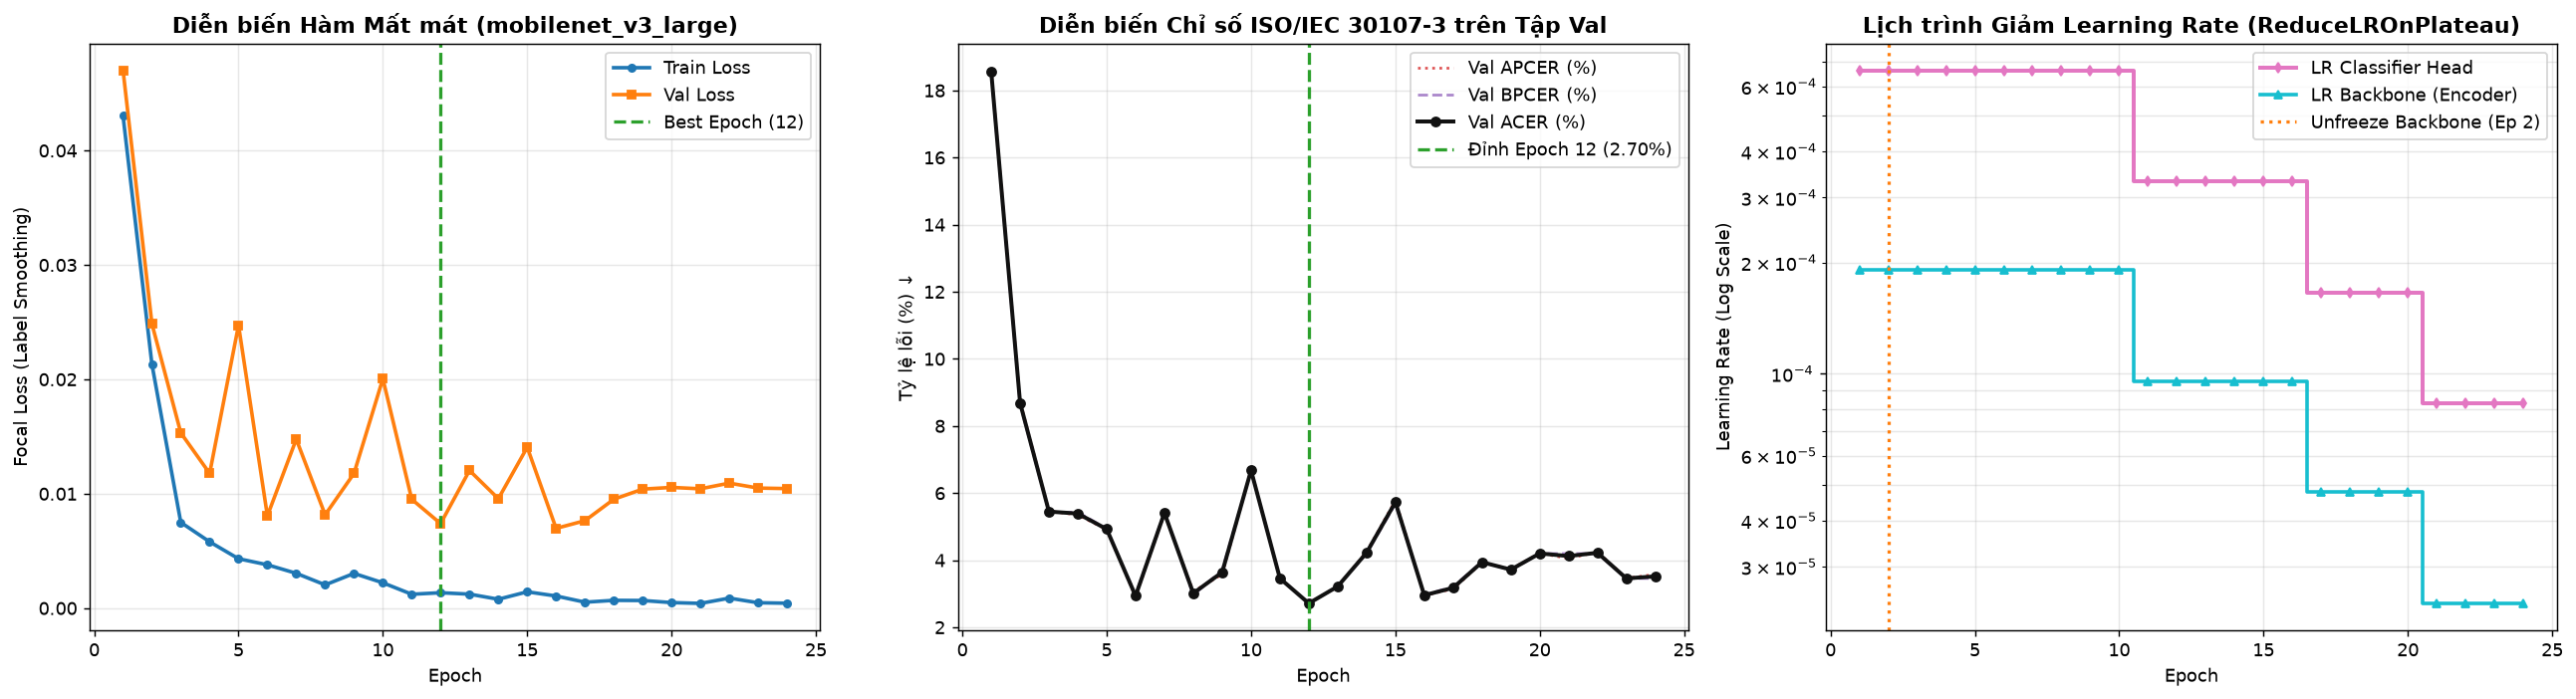

💾 Đã lưu biểu đồ quá trình huấn luyện tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage2/training_curves_stage2.png


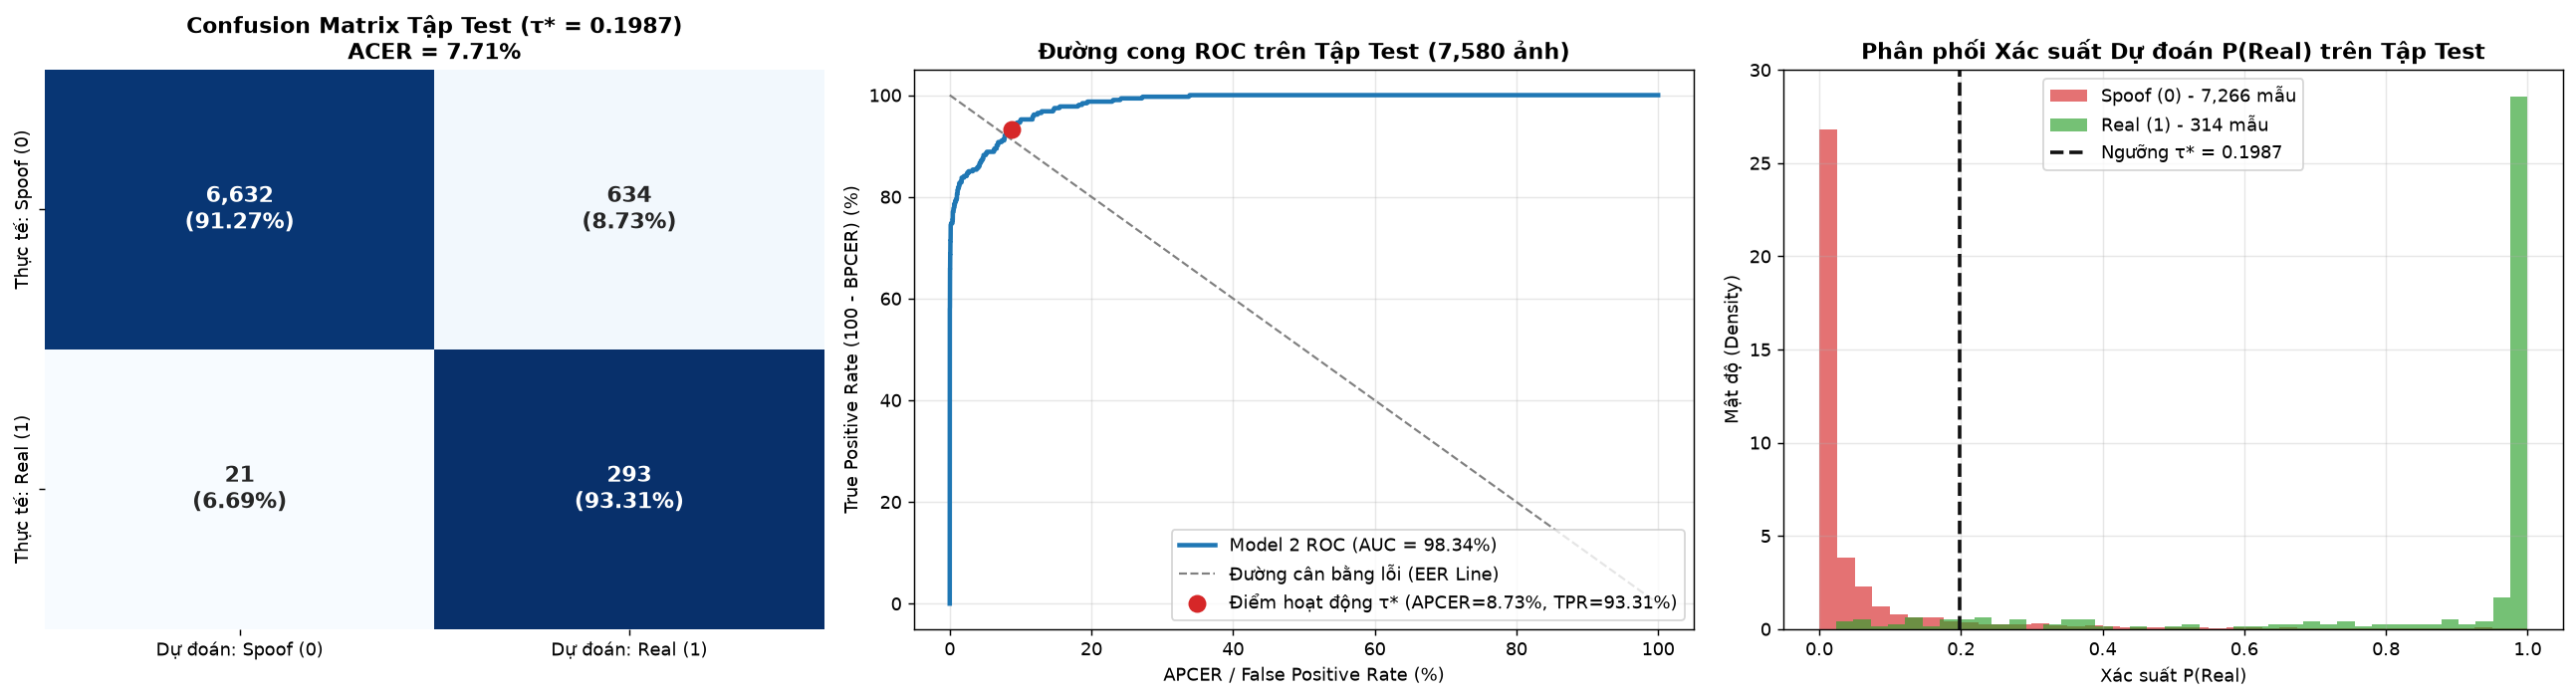

💾 Đã lưu biểu đồ chẩn đoán tập Test tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage2/test_diagnostics_stage2.png


In [15]:
# === CELL 15: TRỰC QUAN HÓA QUÁ TRÌNH HỘI TỤ (CÓ VẠCH GIẢM LR) & CHẨN ĐOÁN TẬP TEST ===
hist_df = pd.read_csv(HISTORY_CSV_PATH)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=130)

# 1. Đường cong Train Loss & Val Loss
ax = axes[0]
ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", markersize=4, label="Train Loss", color="#1f77b4", linewidth=2)
ax.plot(hist_df["epoch"], hist_df["val_loss"],   marker="s", markersize=4, label="Val Loss",   color="#ff7f0e", linewidth=2)
ax.axvline(best_epoch, color="#2ca02c", linestyle="--", linewidth=1.8, label=f"Best Epoch ({best_epoch})")
ax.set_title(f"Diễn biến Hàm Mất mát ({best_backbone})", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Focal Loss (Label Smoothing)")
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Đường cong Val APCER, BPCER, ACER & ROC-AUC
ax = axes[1]
ax.plot(hist_df["epoch"], hist_df["val_APCER"], linestyle=":", label="Val APCER (%)", color="#d62728", alpha=0.8)
ax.plot(hist_df["epoch"], hist_df["val_BPCER"], linestyle="--", label="Val BPCER (%)", color="#9467bd", alpha=0.8)
ax.plot(hist_df["epoch"], hist_df["val_ACER"],  marker="o", markersize=5, label="Val ACER (%)", color="#111111", linewidth=2.2)
ax.axvline(best_epoch, color="#2ca02c", linestyle="--", linewidth=1.8, label=f"Đỉnh Epoch {best_epoch} ({val_final['ACER']:.2f}%)")
ax.set_title("Diễn biến Chỉ số ISO/IEC 30107-3 trên Tập Val", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Tỷ lệ lỗi (%) ↓")
ax.grid(True, alpha=0.3)
ax.legend()

# 3. Biểu đồ Bậc thang Tốc độ học (Learning Rate Schedule) chứng minh ReduceLROnPlateau hoạt động
ax = axes[2]
ax.step(hist_df["epoch"], hist_df["lr_head"], where="mid", marker="d", markersize=4, color="#e377c2", linewidth=2.2, label="LR Classifier Head")
ax.step(hist_df["epoch"], hist_df["lr_backbone"], where="mid", marker="^", markersize=4, color="#17becf", linewidth=2.0, label="LR Backbone (Encoder)")
ax.axvline(FINAL_UNFREEZE_EP, color="#ff7f0e", linestyle=":", linewidth=1.8, label=f"Unfreeze Backbone (Ep {FINAL_UNFREEZE_EP})")
ax.set_yscale("log")
ax.set_title("Lịch trình Giảm Learning Rate (ReduceLROnPlateau)", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate (Log Scale)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
curves_path = ARTIFACTS_DIR / "training_curves_stage2.png"
plt.savefig(curves_path, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu biểu đồ quá trình huấn luyện tại: {curves_path}")

# --- Bộ 3 Biểu đồ Chẩn đoán trên Tập Test (Confusion Matrix, ROC Curve, Phân phối Xác suất) ---
y_true_test = test_fixed["y_true"]
y_prob_test = test_fixed["y_prob"]
y_pred_test = (y_prob_test >= val_threshold).astype(np.int64)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=130)

# 1) Ma trận nhầm lẫn
cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100.0
annot = np.empty_like(cm).astype(str)
for i in range(2):
    for j in range(2):
        annot[i, j] = f"{cm[i, j]:,d}\n({cm_norm[i, j]:.2f}%)"

sns.heatmap(
    cm_norm, annot=annot, fmt="", cmap="Blues", cbar=False, ax=axes[0],
    xticklabels=["Dự đoán: Spoof (0)", "Dự đoán: Real (1)"],
    yticklabels=["Thực tế: Spoof (0)", "Thực tế: Real (1)"],
    annot_kws={"size": 12, "weight": "bold"},
)
axes[0].set_title(f"Confusion Matrix Tập Test (τ* = {val_threshold:.4f})\nACER = {test_fixed['ACER']:.2f}%", fontsize=12, fontweight="bold")

# 2) Đường cong ROC & Điểm EER
fpr, tpr, _ = roc_curve(y_true_test, y_prob_test, pos_label=1)
axes[1].plot(fpr * 100.0, tpr * 100.0, color="#1f77b4", linewidth=2.5, label=f"Model 2 ROC (AUC = {test_fixed['AUC']:.2f}%)")
axes[1].plot([0, 100], [100, 0], color="gray", linestyle="--", linewidth=1.2, label="Đường cân bằng lỗi (EER Line)")
axes[1].scatter([test_fixed["APCER"]], [100.0 - test_fixed["BPCER"]], color="#d62728", s=80, zorder=5, label=f"Điểm hoạt động τ* (APCER={test_fixed['APCER']:.2f}%, TPR={100-test_fixed['BPCER']:.2f}%)")
axes[1].set_title("Đường cong ROC trên Tập Test (7,580 ảnh)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("APCER / False Positive Rate (%)")
axes[1].set_ylabel("True Positive Rate (100 - BPCER) (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="lower right")

# 3) Phân phối xác suất P(Real)
axes[2].hist(y_prob_test[y_true_test == 0], bins=40, alpha=0.65, color="#d62728", label=f"Spoof (0) - {int((y_true_test==0).sum()):,d} mẫu", density=True)
axes[2].hist(y_prob_test[y_true_test == 1], bins=40, alpha=0.65, color="#2ca02c", label=f"Real (1) - {int((y_true_test==1).sum()):,d} mẫu", density=True)
axes[2].axvline(val_threshold, color="#111111", linestyle="--", linewidth=2.0, label=f"Ngưỡng τ* = {val_threshold:.4f}")
axes[2].set_title("Phân phối Xác suất Dự đoán P(Real) trên Tập Test", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Xác suất P(Real)")
axes[2].set_ylabel("Mật độ (Density)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
diag_path = ARTIFACTS_DIR / "test_diagnostics_stage2.png"
plt.savefig(diag_path, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu biểu đồ chẩn đoán tập Test tại: {diag_path}")

🔍 Tổng số lỗi trên 7,580 ảnh Test: False Positive (Lọt giả mạo) = 634 | False Negative (Từ chối thật) = 21


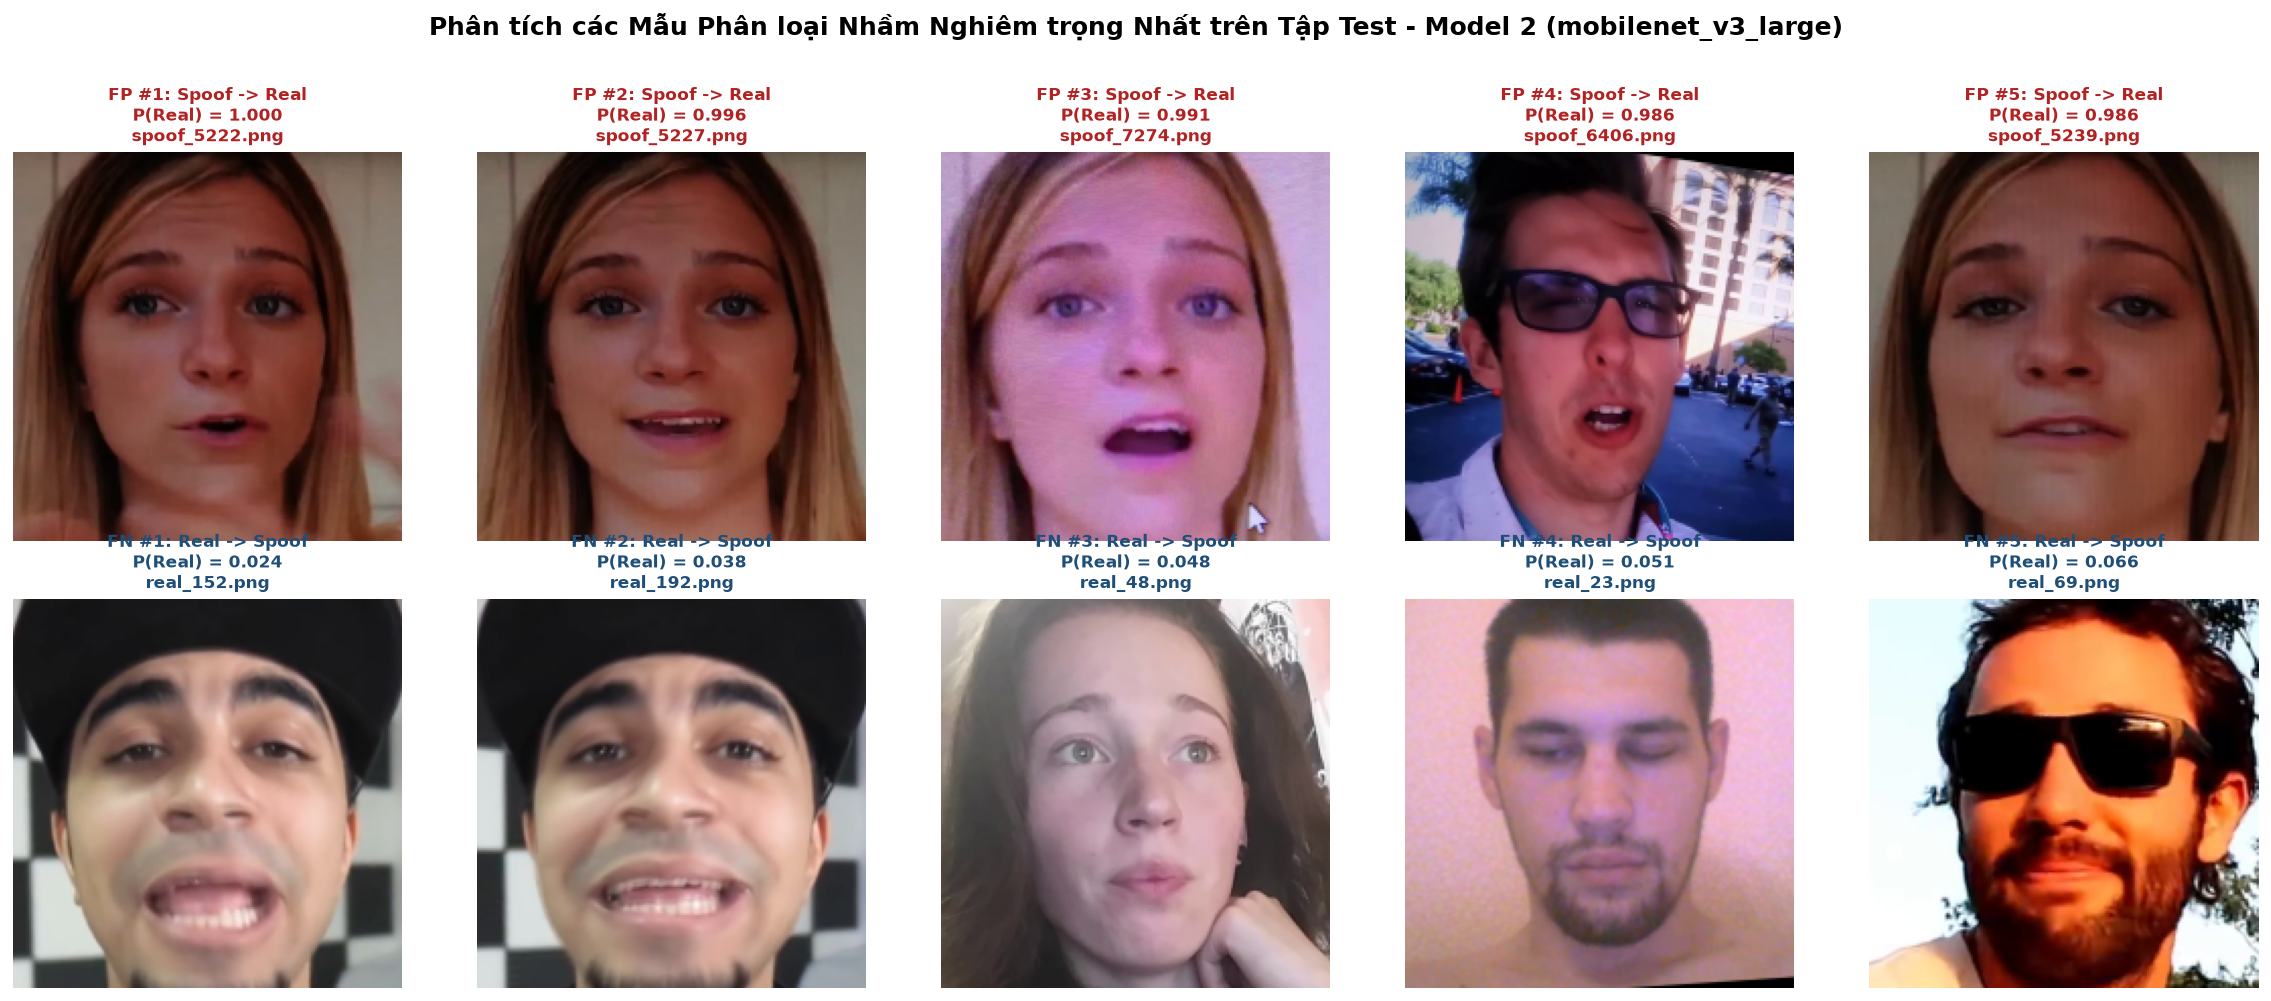

💾 Đã lưu ảnh phân tích lỗi trực quan tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage2/error_analysis_stage2.png


In [16]:
# === CELL 16: PHÂN TÍCH LỖI TRỰC QUAN TRÊN TẬP TEST (VISUAL ERROR ANALYSIS) ===
fp_indices = np.where((y_true_test == 0) & (y_pred_test == 1))[0]
fn_indices = np.where((y_true_test == 1) & (y_pred_test == 0))[0]

# Sắp xếp theo mức độ sai nghiêm trọng nhất (P(Real) cao nhất đối với FP và thấp nhất đối với FN)
fp_sorted = fp_indices[np.argsort(-y_prob_test[fp_indices])][:5]
fn_sorted = fn_indices[np.argsort(y_prob_test[fn_indices])][:5]

print(f"🔍 Tổng số lỗi trên 7,580 ảnh Test: False Positive (Lọt giả mạo) = {len(fp_indices)} | False Negative (Từ chối thật) = {len(fn_indices)}")

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5), dpi=130)
fig.suptitle(f"Phân tích các Mẫu Phân loại Nhầm Nghiêm trọng Nhất trên Tập Test - Model 2 ({best_backbone})", fontsize=14, fontweight="bold", y=1.02)

# Hàng 1: Top 5 False Positives (Spoof -> Real)
for col in range(5):
    ax = axes[0, col]
    if col < len(fp_sorted):
        idx = int(fp_sorted[col])
        img_path, _ = test_samples[idx]
        img_rgb = decode_and_resize_single((img_path, IMG_SIZE))
        ax.imshow(img_rgb)
        ax.set_title(f"FP #{col+1}: Spoof -> Real\nP(Real) = {y_prob_test[idx]:.3f}\n{Path(img_path).name}", fontsize=9.5, color="#b22222", fontweight="bold")
    else:
        ax.text(0.5, 0.5, "Không có mẫu lỗi", ha="center", va="center")
    ax.axis("off")

# Hàng 2: Top 5 False Negatives (Real -> Spoof)
for col in range(5):
    ax = axes[1, col]
    if col < len(fn_sorted):
        idx = int(fn_sorted[col])
        img_path, _ = test_samples[idx]
        img_rgb = decode_and_resize_single((img_path, IMG_SIZE))
        ax.imshow(img_rgb)
        ax.set_title(f"FN #{col+1}: Real -> Spoof\nP(Real) = {y_prob_test[idx]:.3f}\n{Path(img_path).name}", fontsize=9.5, color="#1f4e78", fontweight="bold")
    else:
        ax.text(0.5, 0.5, "Không có mẫu lỗi", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
err_path = ARTIFACTS_DIR / "error_analysis_stage2.png"
plt.savefig(err_path, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu ảnh phân tích lỗi trực quan tại: {err_path}")

# Giải phóng bộ nhớ sau khi hoàn tất toàn bộ Notebook
del eval_model2, val_loader_eval, test_loader_eval
gc.collect()
if has_xpu:
    torch.xpu.empty_cache()